# Clustering of Cacao Flower Microbiome Data

HDBSCAN and GMM clustering on 16S (bacteria) and ITS1 (fungi) CLR-transformed feature tables.
Clusters are compared against sample metadata — in particular `fungal_colonization_score` which showed structure in t-SNE.

**Preprocessing:** same as `01_dim_reduction.ipynb` — CLR transformation on prevalence-filtered ASV tables.

**Pipeline:**
1. Load data (same paths as 01_dim_reduction.ipynb)
2. PCA for dimensionality reduction before clustering
3. HDBSCAN — density-based, no fixed K
4. GMM — distribution-based, soft assignments
5. Clustermap — hierarchical view of raw CLR matrix with metadata annotation
6. Label comparison: do clusters match fungal_colonization_score / other metadata?

## 0. Imports & paths

In [65]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import biom
from skbio.stats.composition import clr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import hdbscan

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

ROOT     = Path('..').resolve()
BIOM_DIR = ROOT / 'results' / 'biom'
DATA_DIR = ROOT / 'data'
FIG_DIR  = ROOT / 'results' / 'figures' / 'clustering'
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print('Paths OK')

Paths OK


## 1. Load data
Identical to `01_dim_reduction.ipynb` — same BIOM tables and metadata.

In [66]:
tbl_16s  = biom.load_table(str(BIOM_DIR / 'cfm_16s_bacteria_biosamples_feature-table.biom'))
tbl_its1 = biom.load_table(str(BIOM_DIR / 'cfm_its1_fungi_biosamples_feature-table.biom'))

counts_16s  = tbl_16s.to_dataframe(dense=True).T   # samples x ASVs
counts_its1 = tbl_its1.to_dataframe(dense=True).T

print(f'16S  raw: {counts_16s.shape}')
print(f'ITS1 raw: {counts_its1.shape}')

16S  raw: (294, 25035)
ITS1 raw: (294, 11929)


In [67]:
meta_raw = pd.read_csv(
    DATA_DIR / 'sample_metadata_with_microscopy.txt',
    sep='\t', index_col=0, dtype=str
)
meta = meta_raw.drop(index='#q2:types', errors='ignore').copy()

num_cols = [
    'dna_conc_hs_16s', 'dna_conc_hs_its1',
    'pi_dic', 'pi_clsm', 'callose_plug_index', 'fungal_colonization_score'
]
for col in num_cols:
    if col in meta.columns:
        meta[col] = (
            meta[col].str.replace(',', '.', regex=False)
                     .pipe(pd.to_numeric, errors='coerce')
        )

print(f'Metadata: {meta.shape}')
print('fungal_colonization_score value counts:')
print(meta['fungal_colonization_score'].value_counts().sort_index())

Metadata: (337, 34)
fungal_colonization_score value counts:
fungal_colonization_score
0.0    120
1.0     14
2.0     15
3.0      7
4.0      8
5.0     20
Name: count, dtype: int64


## 2. Preprocessing: prevalence filter + CLR

In [68]:
def filter_counts(counts_df, min_prevalence=0.05, min_total=10):
    n_samples  = counts_df.shape[0]
    prevalence = (counts_df > 0).sum(axis=0) / n_samples
    total      = counts_df.sum(axis=0)
    keep       = (prevalence >= min_prevalence) & (total >= min_total)
    return counts_df.loc[:, keep]

def multiplicative_replacement(mat, delta=None):
    mat = np.asarray(mat, dtype=float)
    n   = mat.shape[1]
    if delta is None:
        delta = 1.0 / n ** 2
    result = mat.copy()
    for i in range(len(result)):
        zm = result[i] == 0
        k  = zm.sum()
        if k:
            result[i, zm]   = delta
            result[i, ~zm] *= (1 - k * delta)
    return result

def prepare_clr(counts_df):
    """Prevalence-filtered CLR (Aitchison geometry)."""
    mat  = multiplicative_replacement(counts_df.values)
    clr_ = clr(mat)
    return pd.DataFrame(clr_, index=counts_df.index, columns=counts_df.columns)

# Filter and transform
counts_16s_f  = filter_counts(counts_16s,  min_prevalence=0.05)
counts_its1_f = filter_counts(counts_its1, min_prevalence=0.05)

clr_16s  = prepare_clr(counts_16s_f)
clr_its1 = prepare_clr(counts_its1_f)

print(f'CLR 16S  : {clr_16s.shape}   (samples x ASVs)')
print(f'CLR ITS1 : {clr_its1.shape}  (samples x ASVs)')

CLR 16S  : (294, 580)   (samples x ASVs)
CLR ITS1 : (294, 540)  (samples x ASVs)


## 3. PCA for dimensionality reduction before clustering

We use PCA to reduce CLR-transformed data before running HDBSCAN and GMM.
Euclidean distance in CLR space = Aitchison distance, so PCA preserves the compositional geometry.

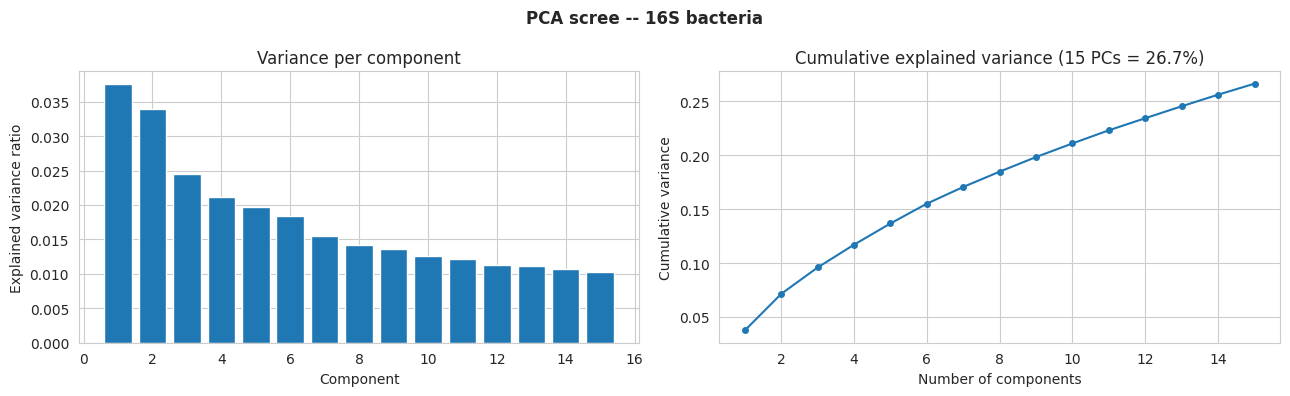

16S bacteria: 294 samples, 580 ASVs
  Using 15 PCs -> explains 26.7% variance


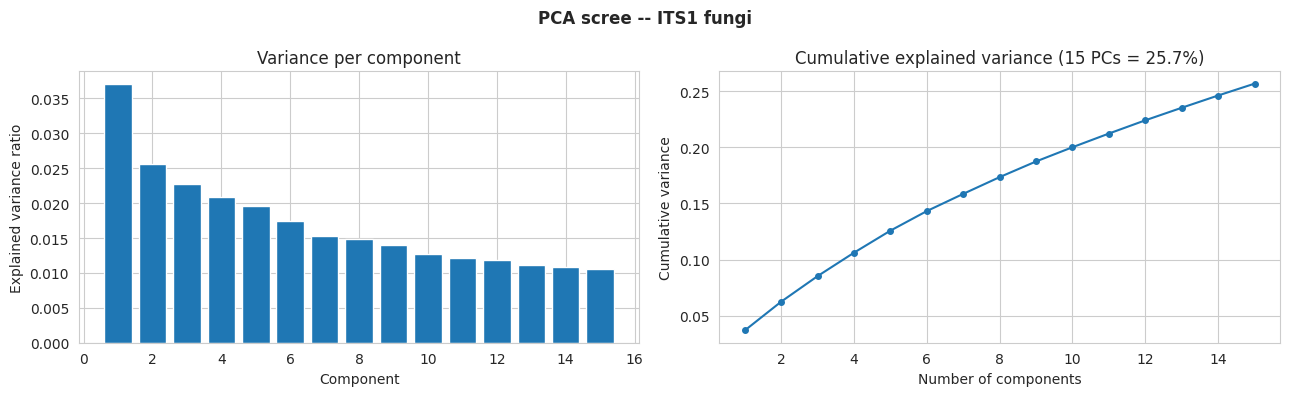

ITS1 fungi: 294 samples, 540 ASVs
  Using 15 PCs -> explains 25.7% variance


In [69]:
def pca_reduce(clr_df, name, n_components=15):
    """
    Fit PCA, print scree info, return (pcs_array, n_components_used).
    Fixed n_components avoids high-dimensional spaces that break HDBSCAN.
    """
    n_max = min(clr_df.shape) - 1
    n_use = min(n_components, n_max)
    pca   = PCA(n_components=n_use, random_state=RANDOM_STATE)
    pcs   = pca.fit_transform(clr_df.values)
    ev    = pca.explained_variance_ratio_
    cumvar = np.cumsum(ev)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'PCA scree -- {name}', fontsize=12, fontweight='bold')
    axes[0].bar(range(1, n_use + 1), ev)
    axes[0].set(xlabel='Component', ylabel='Explained variance ratio',
                title='Variance per component')
    axes[1].plot(range(1, n_use + 1), cumvar, marker='o', markersize=4)
    axes[1].set(xlabel='Number of components', ylabel='Cumulative variance',
                title=f'Cumulative explained variance ({n_use} PCs = {cumvar[-1]:.1%})')
    plt.tight_layout(); plt.show()

    print(f'{name}: {clr_df.shape[0]} samples, {clr_df.shape[1]} ASVs')
    print(f'  Using {n_use} PCs -> explains {cumvar[-1]:.1%} variance')
    return pcs, n_use

pcs_16s,  n_16s  = pca_reduce(clr_16s,  '16S bacteria',  n_components=15)
pcs_its1, n_its1 = pca_reduce(clr_its1, 'ITS1 fungi',    n_components=15)

meta_16s  = meta.reindex(clr_16s.index)
meta_its1 = meta.reindex(clr_its1.index)

## 4. Helper: cluster-vs-metadata comparison

For each cluster label, show the distribution of a metadata variable.
This is the key diagnostic: do clusters align with biology?

In [70]:
def plot_cluster_vs_meta(cluster_labels, meta_aligned, meta_vars, title=''): 
    """
    Stacked bar: composition of each cluster by metadata variable.
    Noise points (label=-1) are excluded from bars but noted in title.
    """
    noise_mask = cluster_labels == -1
    unique_cl  = np.unique(cluster_labels[~noise_mask])
    n_vars = len(meta_vars)
    fig, axes = plt.subplots(1, n_vars, figsize=(5 * n_vars, 4))
    if n_vars == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=12, fontweight='bold')

    for ax, var in zip(axes, meta_vars):
        series = meta_aligned[var] if var in meta_aligned.columns else pd.Series(
            index=meta_aligned.index, dtype=object)
        vals = sorted(series.dropna().unique(), key=str)
        mat  = pd.DataFrame(index=unique_cl, columns=[str(v) for v in vals], data=0.0)
        for k in unique_cl:
            s = series[cluster_labels == k].dropna()
            for v, cnt in s.value_counts().items():
                if str(v) in mat.columns:
                    mat.loc[k, str(v)] = cnt
        mat = mat.div(mat.sum(axis=1), axis=0)
        mat.plot(kind='bar', stacked=True, ax=ax,
                 colormap='tab10', legend=True, width=0.7)
        ax.set(xlabel='Cluster', ylabel='Fraction')
        ax.set_title(f'{var}\n(noise: {noise_mask.mean():.1%})', fontsize=10)
        ax.legend(fontsize=7, bbox_to_anchor=(1, 1))
        ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()


def plot_embedding_colored(coords_2d, cluster_labels, meta_aligned, meta_var,
                           palette=None, title=''):
    """
    Two scatter plots side by side:
      left  -- HDBSCAN cluster labels (noise = grey, clusters = colours)
      right -- metadata variable coloured the same way
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=12, fontweight='bold')

    # ── Left: cluster labels ──────────────────────────────────────────
    ax = axes[0]
    non_noise_mask = cluster_labels != -1
    unique_cl = np.unique(cluster_labels[non_noise_mask])
    pal = sns.color_palette('colorblind', len(unique_cl))

    # noise first (background)
    ax.scatter(coords_2d[~non_noise_mask, 0], coords_2d[~non_noise_mask, 1],
               s=12, color='lightgrey', alpha=0.4, label=f'noise ({(~non_noise_mask).mean():.0%})',
               zorder=1)
    for k, color in zip(unique_cl, pal):
        mask = cluster_labels == k
        ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                   s=25, color=color, alpha=0.8, label=f'Cluster {k}', zorder=2)

    ax.set_title('Cluster labels', fontsize=11)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8, markerscale=1.5)

    # ── Right: metadata variable ──────────────────────────────────────
    ax = axes[1]
    if meta_var not in meta_aligned.columns:
        ax.set_title(f'{meta_var} (not in metadata)')
    else:
        series = meta_aligned[meta_var]
        # convert to string key for lookup
        def to_str_key(x):
            if pd.isna(x): return 'NaN'
            try: return str(int(float(x)))
            except: return str(x)
        keys   = series.apply(to_str_key)
        unique_vals = [v for v in keys.unique() if v != 'NaN']
        pal2   = sns.color_palette('colorblind', len(unique_vals))
        cmap   = dict(zip(unique_vals, pal2))

        nan_mask = keys == 'NaN'
        if nan_mask.any():
            ax.scatter(coords_2d[nan_mask, 0], coords_2d[nan_mask, 1],
                       s=12, color='lightgrey', alpha=0.3, label='NaN', zorder=1)
        for val, color in cmap.items():
            if palette and val in palette:
                color = palette[val]
            mask = keys == val
            ax.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                       s=25, color=color, alpha=0.8, label=val, zorder=2)

        ax.set_title(meta_var, fontsize=11)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
        ax.legend(fontsize=7, markerscale=1.5, ncol=2)

    plt.tight_layout()
    plt.show()

## 5. HDBSCAN clustering
### 5a. 16S bacteria

16S: 294 samples -> trying mcs up to 58
  mcs=  3 ms= 3 -> clusters=2, noise=81.3%, sil=0.084
  mcs=  3 ms= 3 -> clusters=2, noise=81.3%, sil=0.084
  mcs=  3 ms= 3 -> clusters=2, noise=81.3%, sil=0.084
  mcs=  5 ms= 3 -> clusters=2, noise=81.3%, sil=0.084
  mcs=  5 ms= 5 -> clusters=0, noise=100.0%, sil=NaN
  mcs=  5 ms= 5 -> clusters=0, noise=100.0%, sil=NaN
  mcs=  8 ms= 3 -> clusters=0, noise=100.0%, sil=NaN
  mcs=  8 ms= 5 -> clusters=0, noise=100.0%, sil=NaN
  mcs=  8 ms= 8 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 12 ms= 3 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 12 ms= 5 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 12 ms=10 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 20 ms= 3 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 20 ms= 5 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 20 ms=10 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 35 ms= 3 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 35 ms= 5 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 35 ms=10 -> clusters=0, noise=100.0%, sil=NaN


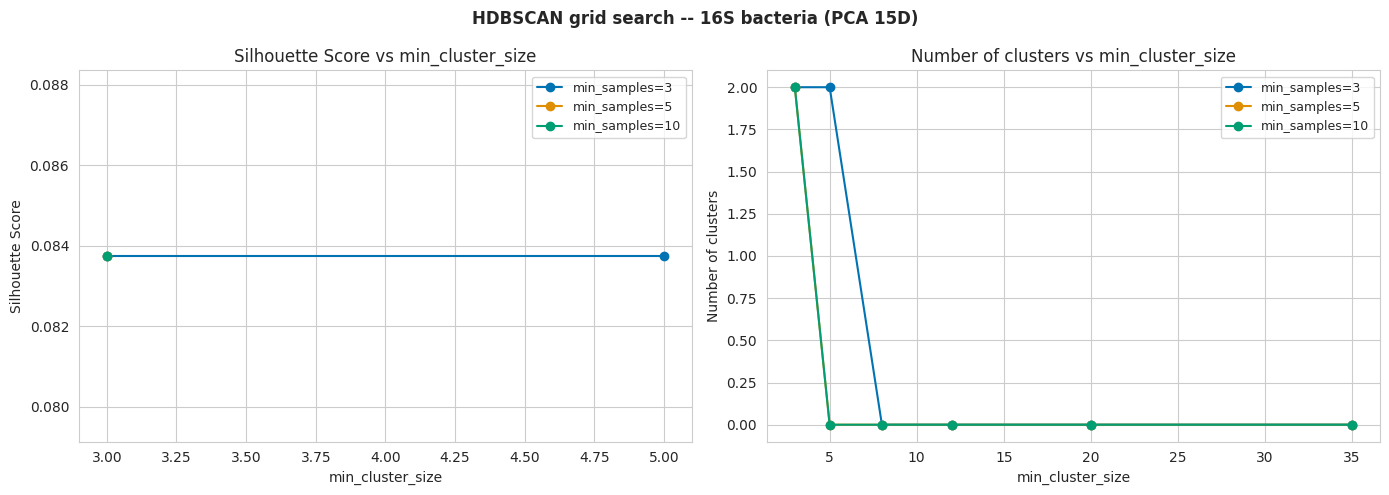


Best 16S HDBSCAN: mcs=3, ms=3
  Clusters=2, noise=81.3%, sil=0.0837


In [71]:
# Grid search: min_cluster_size x min_samples
# Rule of thumb: min_cluster_size ~ sqrt(n_samples); here start very small
n_samples_16s = pcs_16s.shape[0]
print(f"16S: {n_samples_16s} samples -> trying mcs up to {n_samples_16s // 5}")

mcs_grid = [3, 5, 8, 12, 20, 35]
ms_grid  = [3, 5, 10]

rows_16s = []
for mcs in mcs_grid:
    for ms in ms_grid:
        ms_eff = min(ms, mcs)  # min_samples cannot exceed min_cluster_size
        hdb = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms_eff,
                              metric='euclidean')
        lbl = hdb.fit_predict(pcs_16s)
        n_cl      = len(set(lbl) - {-1})
        noise     = (lbl == -1).mean()
        non_noise = lbl != -1
        sil = silhouette_score(pcs_16s[non_noise], lbl[non_noise]) \
              if n_cl >= 2 and non_noise.sum() > n_cl else np.nan
        rows_16s.append({'mcs': mcs, 'ms_orig': ms, 'ms': ms_eff, 'n_cl': n_cl,
                         'noise': noise, 'sil': sil, 'labels': lbl})
        print(f"  mcs={mcs:3d} ms={ms_eff:2d} -> clusters={n_cl}, noise={noise:.1%}, "
              f"sil={sil:.3f}" if not np.isnan(sil) else
              f"  mcs={mcs:3d} ms={ms_eff:2d} -> clusters={n_cl}, noise={noise:.1%}, sil=NaN")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HDBSCAN grid search -- 16S bacteria (PCA 15D)', fontsize=12, fontweight='bold')
pal_ms = sns.color_palette('colorblind', len(ms_grid))
for ax, key, ylabel in zip(axes, ['sil', 'n_cl'],
                           ['Silhouette Score', 'Number of clusters']):
    for ms_orig, color in zip(ms_grid, pal_ms):
        subset = [r for r in rows_16s if r['ms_orig'] == ms_orig]
        xs = [r['mcs'] for r in subset]
        ys = [r[key]  for r in subset]
        ax.plot(xs, ys, marker='o', label=f'min_samples={ms_orig}', color=color)
    ax.set(xlabel='min_cluster_size', ylabel=ylabel,
           title=f'{ylabel} vs min_cluster_size')
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

valid_16s = [r for r in rows_16s if not np.isnan(r['sil'])]
if valid_16s:
    best_16s = max(valid_16s, key=lambda r: r['sil'])
else:
    # Fallback: pick config with most clusters and least noise
    best_16s = max(rows_16s, key=lambda r: (r['n_cl'], -r['noise']))
    print("WARNING: no config with >=2 clusters found. Fallback to most clusters.")

print(f"\nBest 16S HDBSCAN: mcs={best_16s['mcs']}, ms={best_16s['ms']}")
print(f"  Clusters={best_16s['n_cl']}, noise={best_16s['noise']:.1%}, "
      f"sil={best_16s['sil']:.4f}" if not np.isnan(best_16s['sil']) else
      f"  Clusters={best_16s['n_cl']}, noise={best_16s['noise']:.1%}, sil=NaN")
hdb_labels_16s = best_16s['labels']

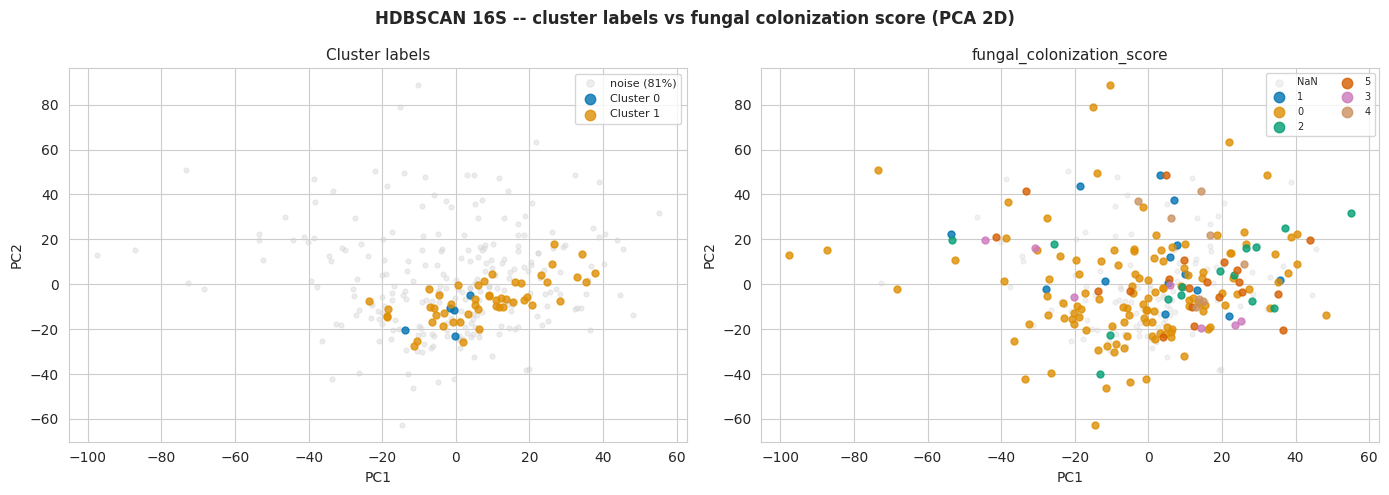

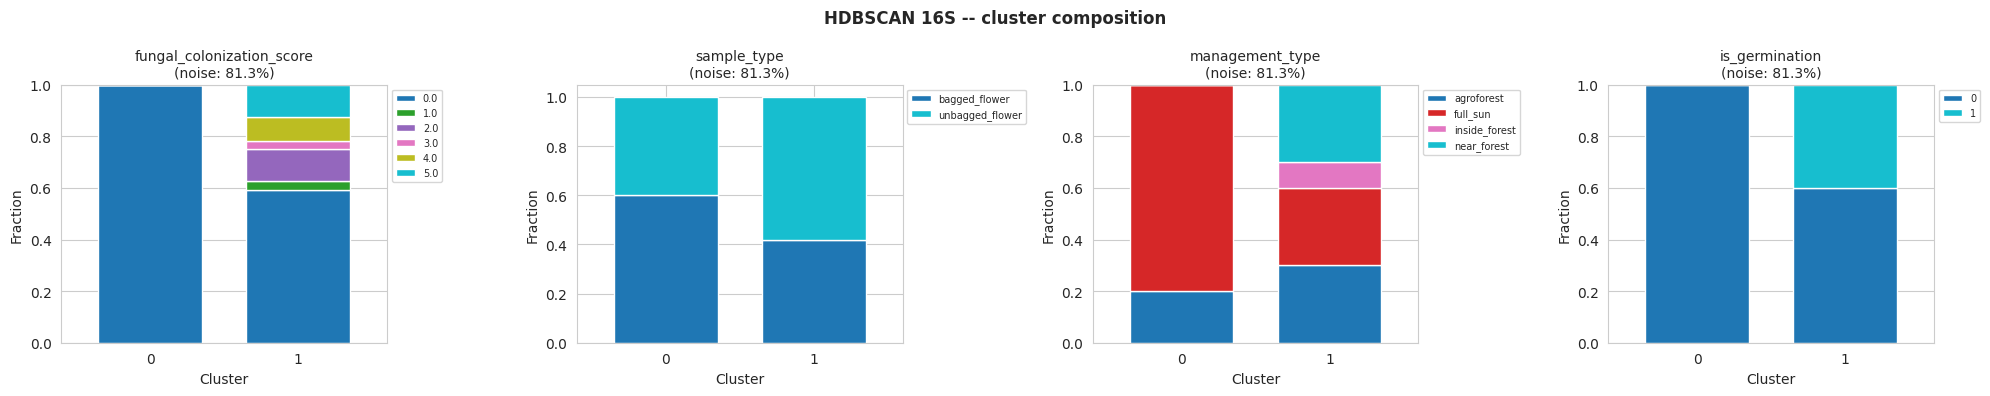

In [72]:
# --- Visualize: cluster labels vs fungal_colonization_score ---
# Using PCA 2D projection for visualization
pca_2d_16s = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(clr_16s.values)

fcs_palette = {
    '0': '#F7F7F7', '1': '#FEE08B', '2': '#FDAE61',
    '3': '#F46D43', '4': '#D73027', '5': '#B30000'
}

plot_embedding_colored(
    pca_2d_16s, hdb_labels_16s, meta_16s,
    meta_var='fungal_colonization_score',
    title='HDBSCAN 16S -- cluster labels vs fungal colonization score (PCA 2D)'
)

plot_cluster_vs_meta(
    hdb_labels_16s, meta_16s,
    meta_vars=['fungal_colonization_score', 'sample_type', 'management_type', 'is_germination'],
    title='HDBSCAN 16S -- cluster composition'
)

### 5b. ITS1 fungi
t-SNE showed structure in ITS1 coloured by `fungal_colonization_score` -- the main hypothesis to test.

  mcs=  3 ms= 3 -> clusters=3, noise=29.6%, sil=0.073
  mcs=  3 ms= 3 -> clusters=3, noise=29.6%, sil=0.073
  mcs=  3 ms= 3 -> clusters=3, noise=29.6%, sil=0.073
  mcs=  5 ms= 3 -> clusters=2, noise=48.3%, sil=0.203
  mcs=  5 ms= 5 -> clusters=0, noise=100.0%, sil=NaN
  mcs=  5 ms= 5 -> clusters=0, noise=100.0%, sil=NaN
  mcs=  8 ms= 3 -> clusters=0, noise=100.0%, sil=NaN
  mcs=  8 ms= 5 -> clusters=0, noise=100.0%, sil=NaN
  mcs=  8 ms= 8 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 12 ms= 3 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 12 ms= 5 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 12 ms=10 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 20 ms= 3 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 20 ms= 5 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 20 ms=10 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 35 ms= 3 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 35 ms= 5 -> clusters=0, noise=100.0%, sil=NaN
  mcs= 35 ms=10 -> clusters=0, noise=100.0%, sil=NaN


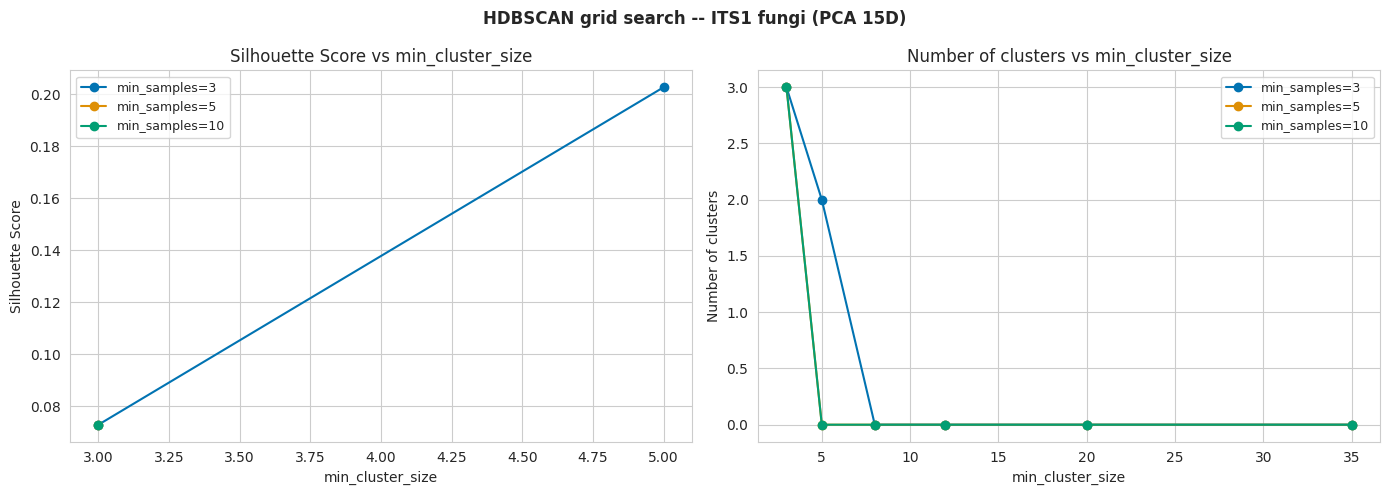


Best ITS1 HDBSCAN: mcs=5, ms=3
  Clusters=2, noise=48.3%, sil=0.2027


In [73]:
mcs_grid = [3, 5, 8, 12, 20, 35]
ms_grid  = [3, 5, 10]

rows_its1 = []
for mcs in mcs_grid:
    for ms in ms_grid:
        ms_eff = min(ms, mcs)
        hdb = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms_eff,
                              metric='euclidean')
        lbl = hdb.fit_predict(pcs_its1)
        n_cl      = len(set(lbl) - {-1})
        noise     = (lbl == -1).mean()
        non_noise = lbl != -1
        sil = silhouette_score(pcs_its1[non_noise], lbl[non_noise]) \
              if n_cl >= 2 and non_noise.sum() > n_cl else np.nan
        # Store original ms for grouping in the plot
        rows_its1.append({'mcs': mcs, 'ms_orig': ms, 'ms': ms_eff,
                          'n_cl': n_cl, 'noise': noise, 'sil': sil, 'labels': lbl})
        print(f"  mcs={mcs:3d} ms={ms_eff:2d} -> clusters={n_cl}, noise={noise:.1%}, " +
              (f"sil={sil:.3f}" if not np.isnan(sil) else "sil=NaN"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('HDBSCAN grid search -- ITS1 fungi (PCA 15D)', fontsize=12, fontweight='bold')
pal_ms = sns.color_palette('colorblind', len(ms_grid))

for ax, key, ylabel in zip(axes, ['sil', 'n_cl'],
                           ['Silhouette Score', 'Number of clusters']):
    for ms_orig, color in zip(ms_grid, pal_ms):
        # Group by original ms value, one point per mcs value
        subset = [r for r in rows_its1 if r['ms_orig'] == ms_orig]
        xs = [r['mcs'] for r in subset]
        ys = [r[key]  for r in subset]
        ax.plot(xs, ys, marker='o', label=f'min_samples={ms_orig}', color=color)
    ax.set(xlabel='min_cluster_size', ylabel=ylabel,
           title=f'{ylabel} vs min_cluster_size')
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

valid_its1 = [r for r in rows_its1 if not np.isnan(r['sil'])]
if valid_its1:
    best_its1 = max(valid_its1, key=lambda r: r['sil'])
else:
    best_its1 = max(rows_its1, key=lambda r: (r['n_cl'], -r['noise']))
    print("WARNING: no config with >=2 clusters found. Fallback to most clusters.")

print(f"\nBest ITS1 HDBSCAN: mcs={best_its1['mcs']}, ms={best_its1['ms']}")
print(f"  Clusters={best_its1['n_cl']}, noise={best_its1['noise']:.1%}, " +
      (f"sil={best_its1['sil']:.4f}" if not np.isnan(best_its1['sil']) else "sil=NaN"))
hdb_labels_its1 = best_its1['labels']

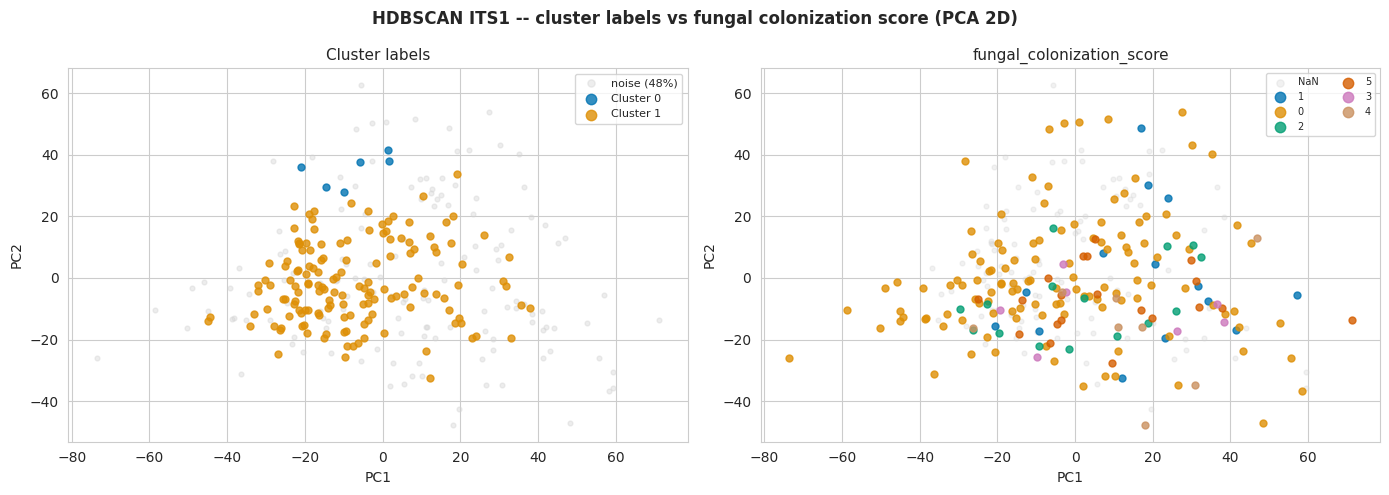

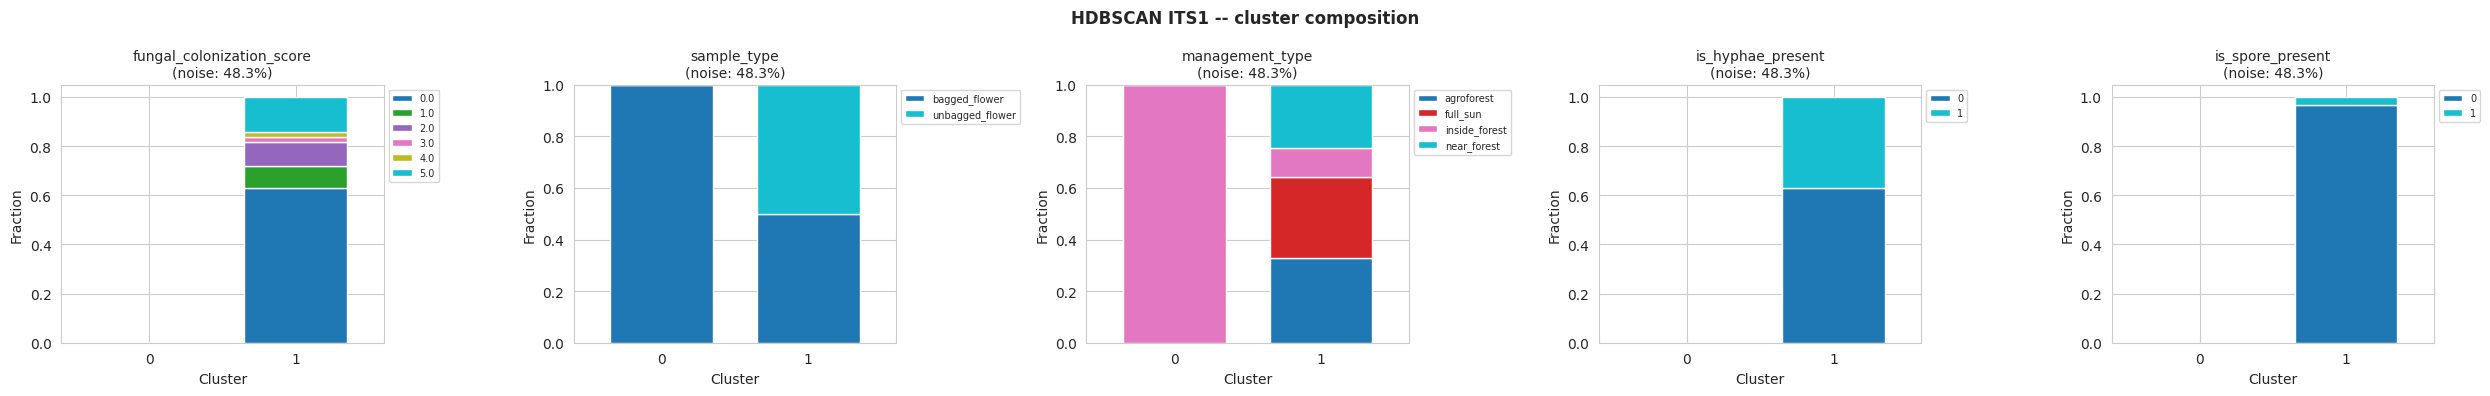

In [74]:
pca_2d_its1 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(clr_its1.values)

plot_embedding_colored(
    pca_2d_its1, hdb_labels_its1, meta_its1,
    meta_var='fungal_colonization_score',
    title='HDBSCAN ITS1 -- cluster labels vs fungal colonization score (PCA 2D)'
)

plot_cluster_vs_meta(
    hdb_labels_its1, meta_its1,
    meta_vars=['fungal_colonization_score', 'sample_type', 'management_type',
               'is_hyphae_present', 'is_spore_present'],
    title='HDBSCAN ITS1 -- cluster composition'
)

## 6. GMM clustering
GMM assigns soft probabilistic labels -- useful when clusters overlap (likely here).
We fix `n_components=5` for fungi (5 levels of fungal_colonization_score) and explore for bacteria.

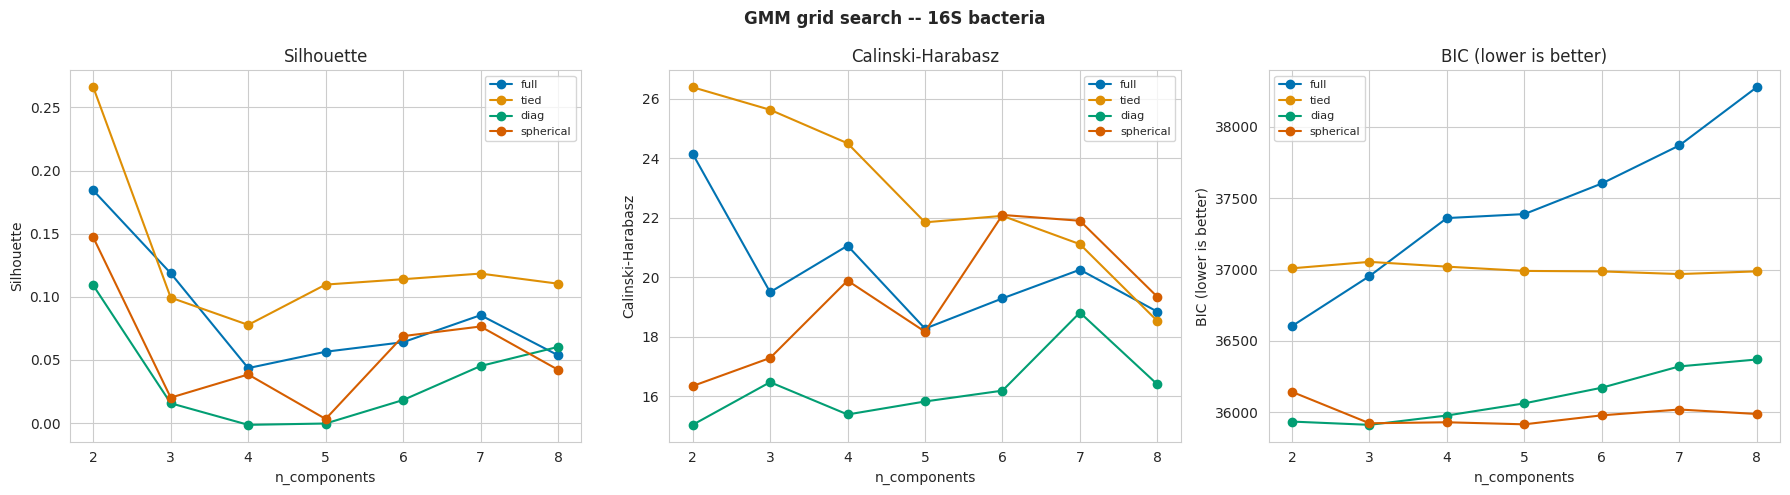

In [75]:
def gmm_grid_search(pcs, name, n_range=range(2, 9), cov_types=None):
    """Grid search over n_components and covariance_type; return results df."""
    if cov_types is None:
        cov_types = ['full', 'tied', 'diag', 'spherical']
    rows = []
    for n in n_range:
        for cov in cov_types:
            np.random.seed(RANDOM_STATE)
            gmm = GaussianMixture(n_components=n, covariance_type=cov,
                                  n_init=5, max_iter=300, random_state=RANDOM_STATE)
            lbl = gmm.fit_predict(pcs)
            sil = silhouette_score(pcs, lbl) if len(set(lbl)) > 1 else np.nan
            ch  = calinski_harabasz_score(pcs, lbl) if len(set(lbl)) > 1 else np.nan
            bic = gmm.bic(pcs)
            rows.append({'n': n, 'cov': cov, 'sil': sil, 'ch': ch,
                         'bic': bic, 'labels': lbl})

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'GMM grid search -- {name}', fontsize=12, fontweight='bold')
    pal = sns.color_palette('colorblind', len(cov_types))
    for ax, key, ylabel, lower_better in zip(
        axes, ['sil', 'ch', 'bic'],
        ['Silhouette', 'Calinski-Harabasz', 'BIC (lower is better)'],
        [False, False, True]
    ):
        for cov, color in zip(cov_types, pal):
            ys = [r[key] for r in rows if r['cov'] == cov]
            ax.plot(list(n_range), ys, marker='o', label=cov, color=color)
        ax.set(xlabel='n_components', ylabel=ylabel, title=ylabel)
        ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    return rows

rows_gmm_16s = gmm_grid_search(pcs_16s, '16S bacteria')

Best GMM 16S: n=2, cov='tied'
  Silhouette=0.2660, CH=26.39, BIC=37008


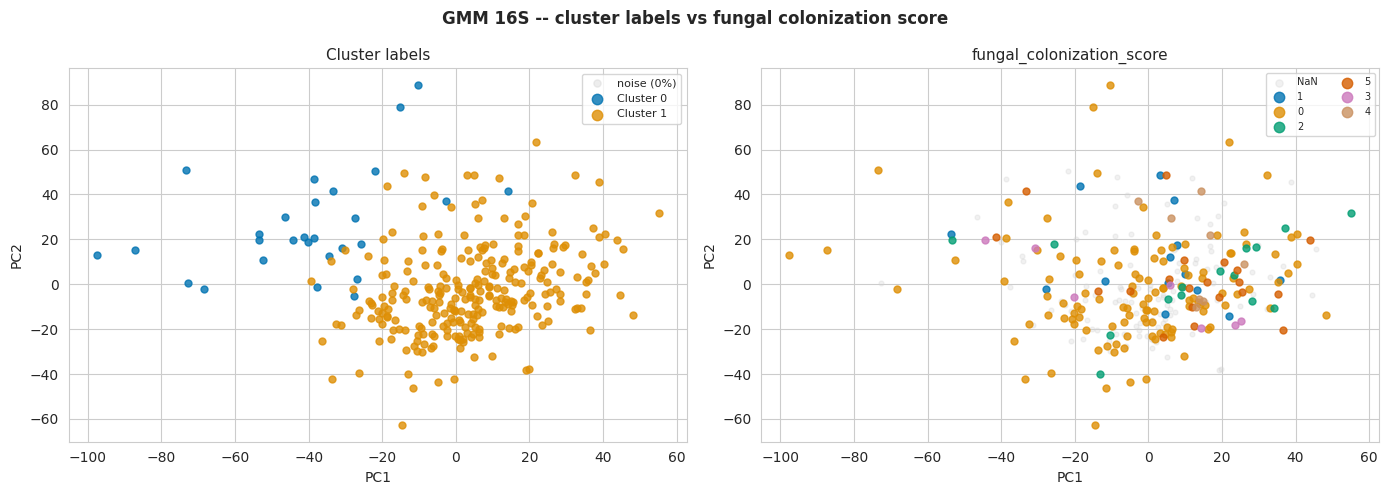

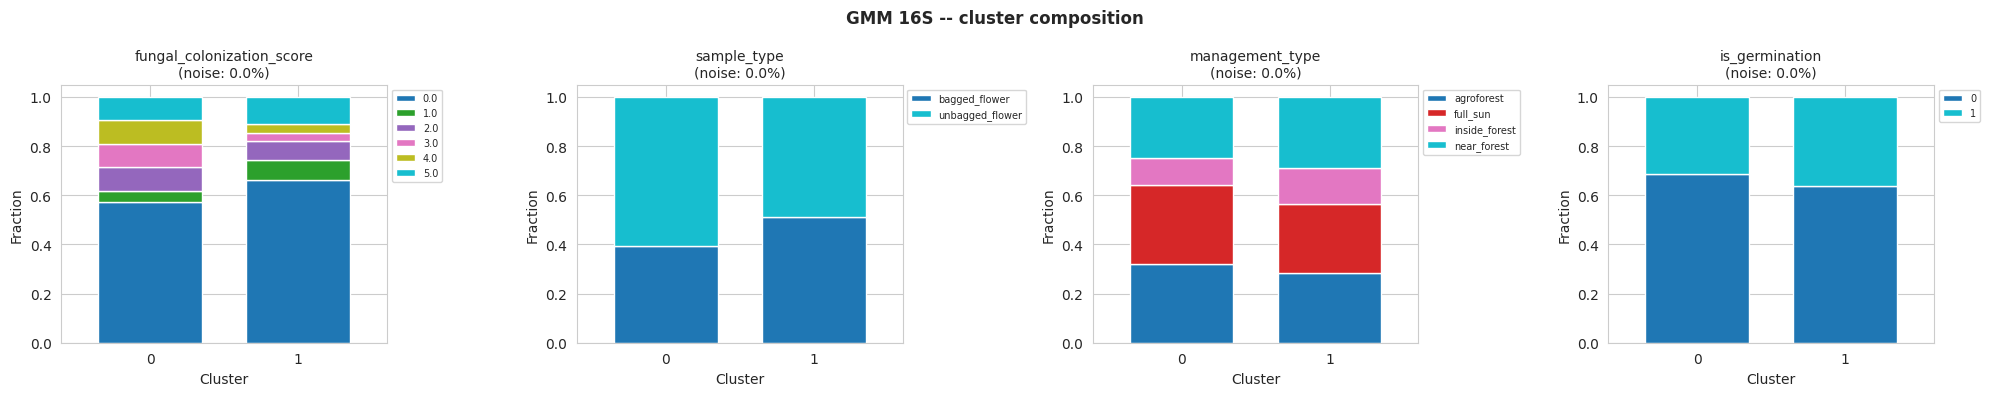

In [76]:
# Best GMM for 16S (by silhouette)
best_gmm_16s = max([r for r in rows_gmm_16s if not np.isnan(r['sil'])],
                   key=lambda r: r['sil'])
print(f"Best GMM 16S: n={best_gmm_16s['n']}, cov='{best_gmm_16s['cov']}'")
print(f"  Silhouette={best_gmm_16s['sil']:.4f}, CH={best_gmm_16s['ch']:.2f}, BIC={best_gmm_16s['bic']:.0f}")
gmm_labels_16s = best_gmm_16s['labels']

plot_embedding_colored(
    pca_2d_16s, gmm_labels_16s, meta_16s,
    meta_var='fungal_colonization_score',
    title='GMM 16S -- cluster labels vs fungal colonization score'
)
plot_cluster_vs_meta(
    gmm_labels_16s, meta_16s,
    meta_vars=['fungal_colonization_score', 'sample_type', 'management_type', 'is_germination'],
    title='GMM 16S -- cluster composition'
)

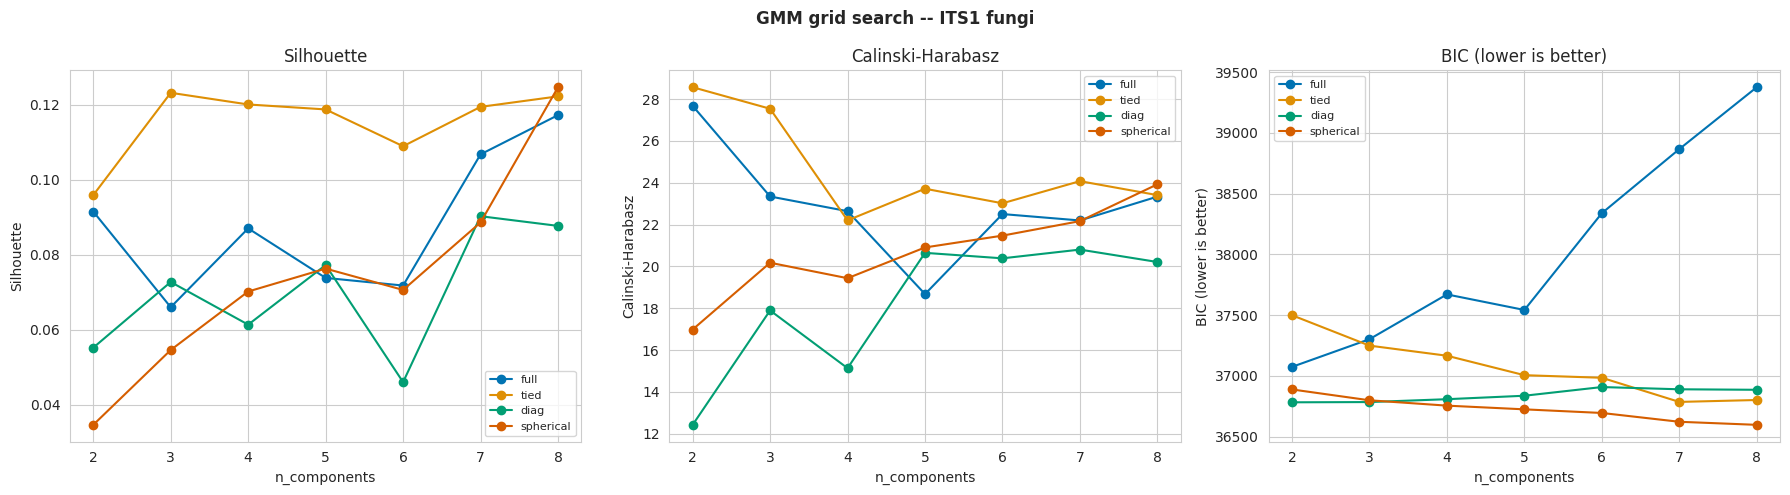

In [77]:
# ITS1 fungi: try n=5 (matches fungal_colonization_score levels 0-5, but score 0 may be rare)
rows_gmm_its1 = gmm_grid_search(pcs_its1, 'ITS1 fungi')

Best GMM ITS1: n=8, cov='spherical'
  Silhouette=0.1247, CH=23.92, BIC=36597


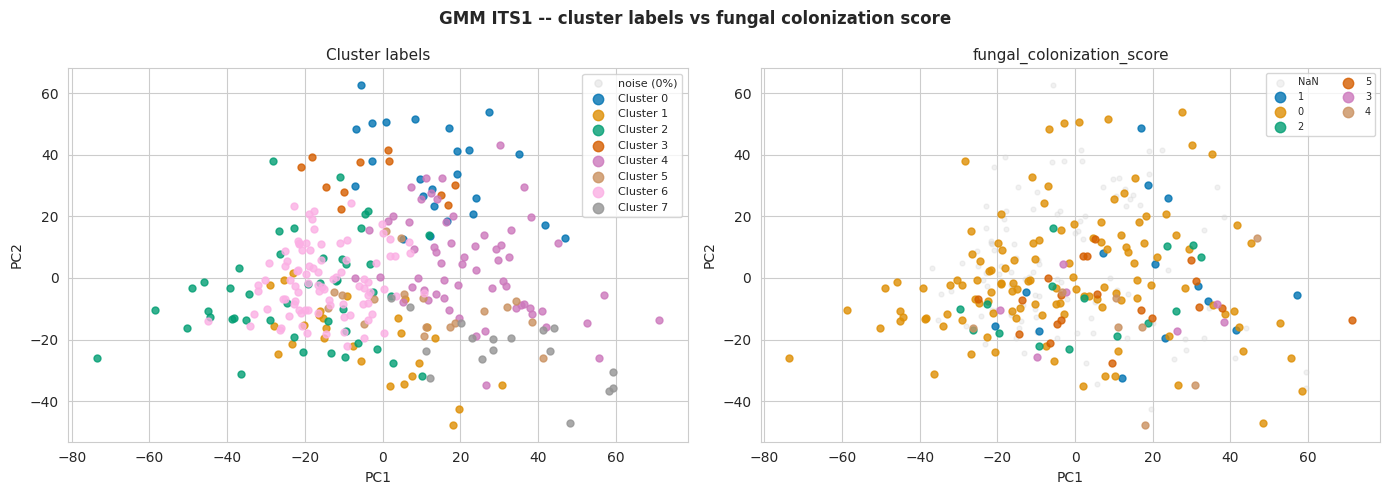

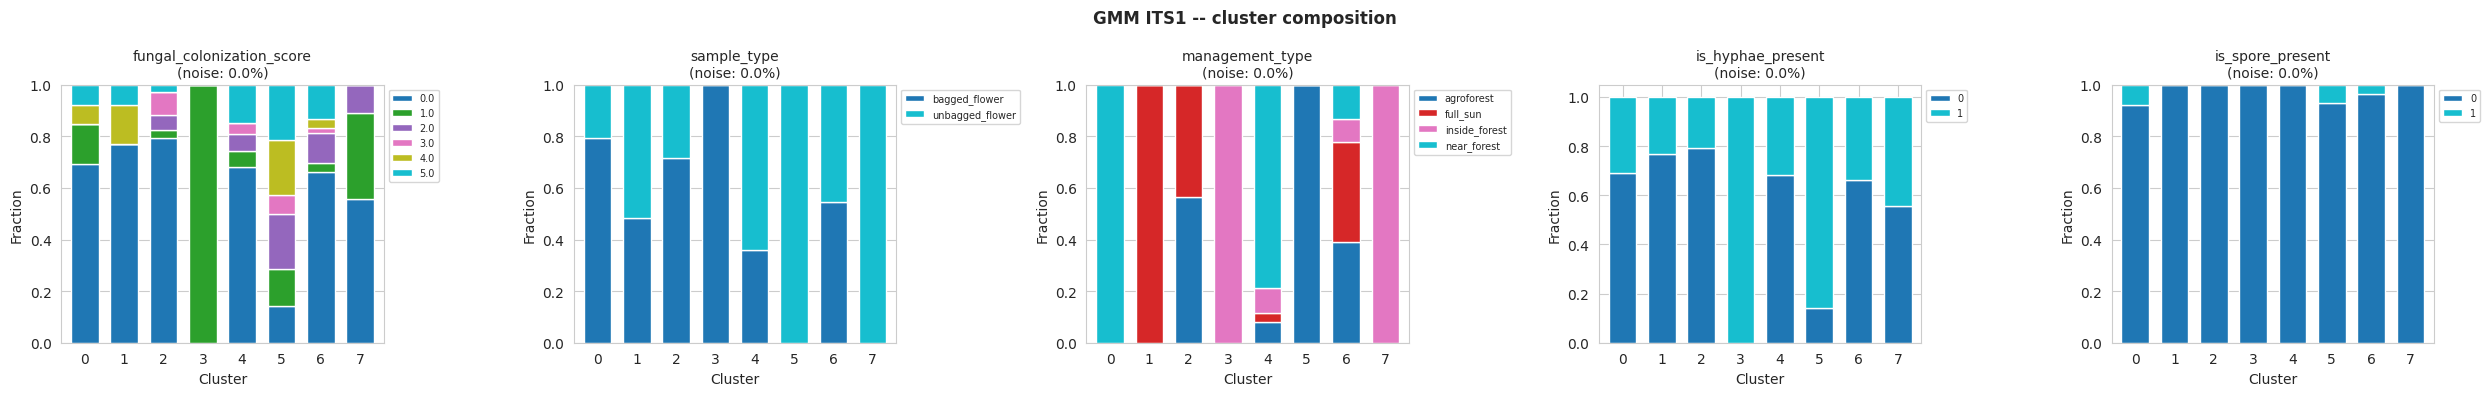

In [78]:
best_gmm_its1 = max([r for r in rows_gmm_its1 if not np.isnan(r['sil'])],
                    key=lambda r: r['sil'])
print(f"Best GMM ITS1: n={best_gmm_its1['n']}, cov='{best_gmm_its1['cov']}'")
print(f"  Silhouette={best_gmm_its1['sil']:.4f}, CH={best_gmm_its1['ch']:.2f}, BIC={best_gmm_its1['bic']:.0f}")
gmm_labels_its1 = best_gmm_its1['labels']

plot_embedding_colored(
    pca_2d_its1, gmm_labels_its1, meta_its1,
    meta_var='fungal_colonization_score',
    title='GMM ITS1 -- cluster labels vs fungal colonization score'
)
plot_cluster_vs_meta(
    gmm_labels_its1, meta_its1,
    meta_vars=['fungal_colonization_score', 'sample_type', 'management_type',
               'is_hyphae_present', 'is_spore_present'],
    title='GMM ITS1 -- cluster composition'
)

## 7. Clustermap
Hierarchical clustering heatmap on the CLR matrix.
Rows = samples annotated by metadata; columns = ASVs reordered by taxonomy similarity.

For readability we subsample to at most 80 samples (ITS1 is smaller and may not need it).

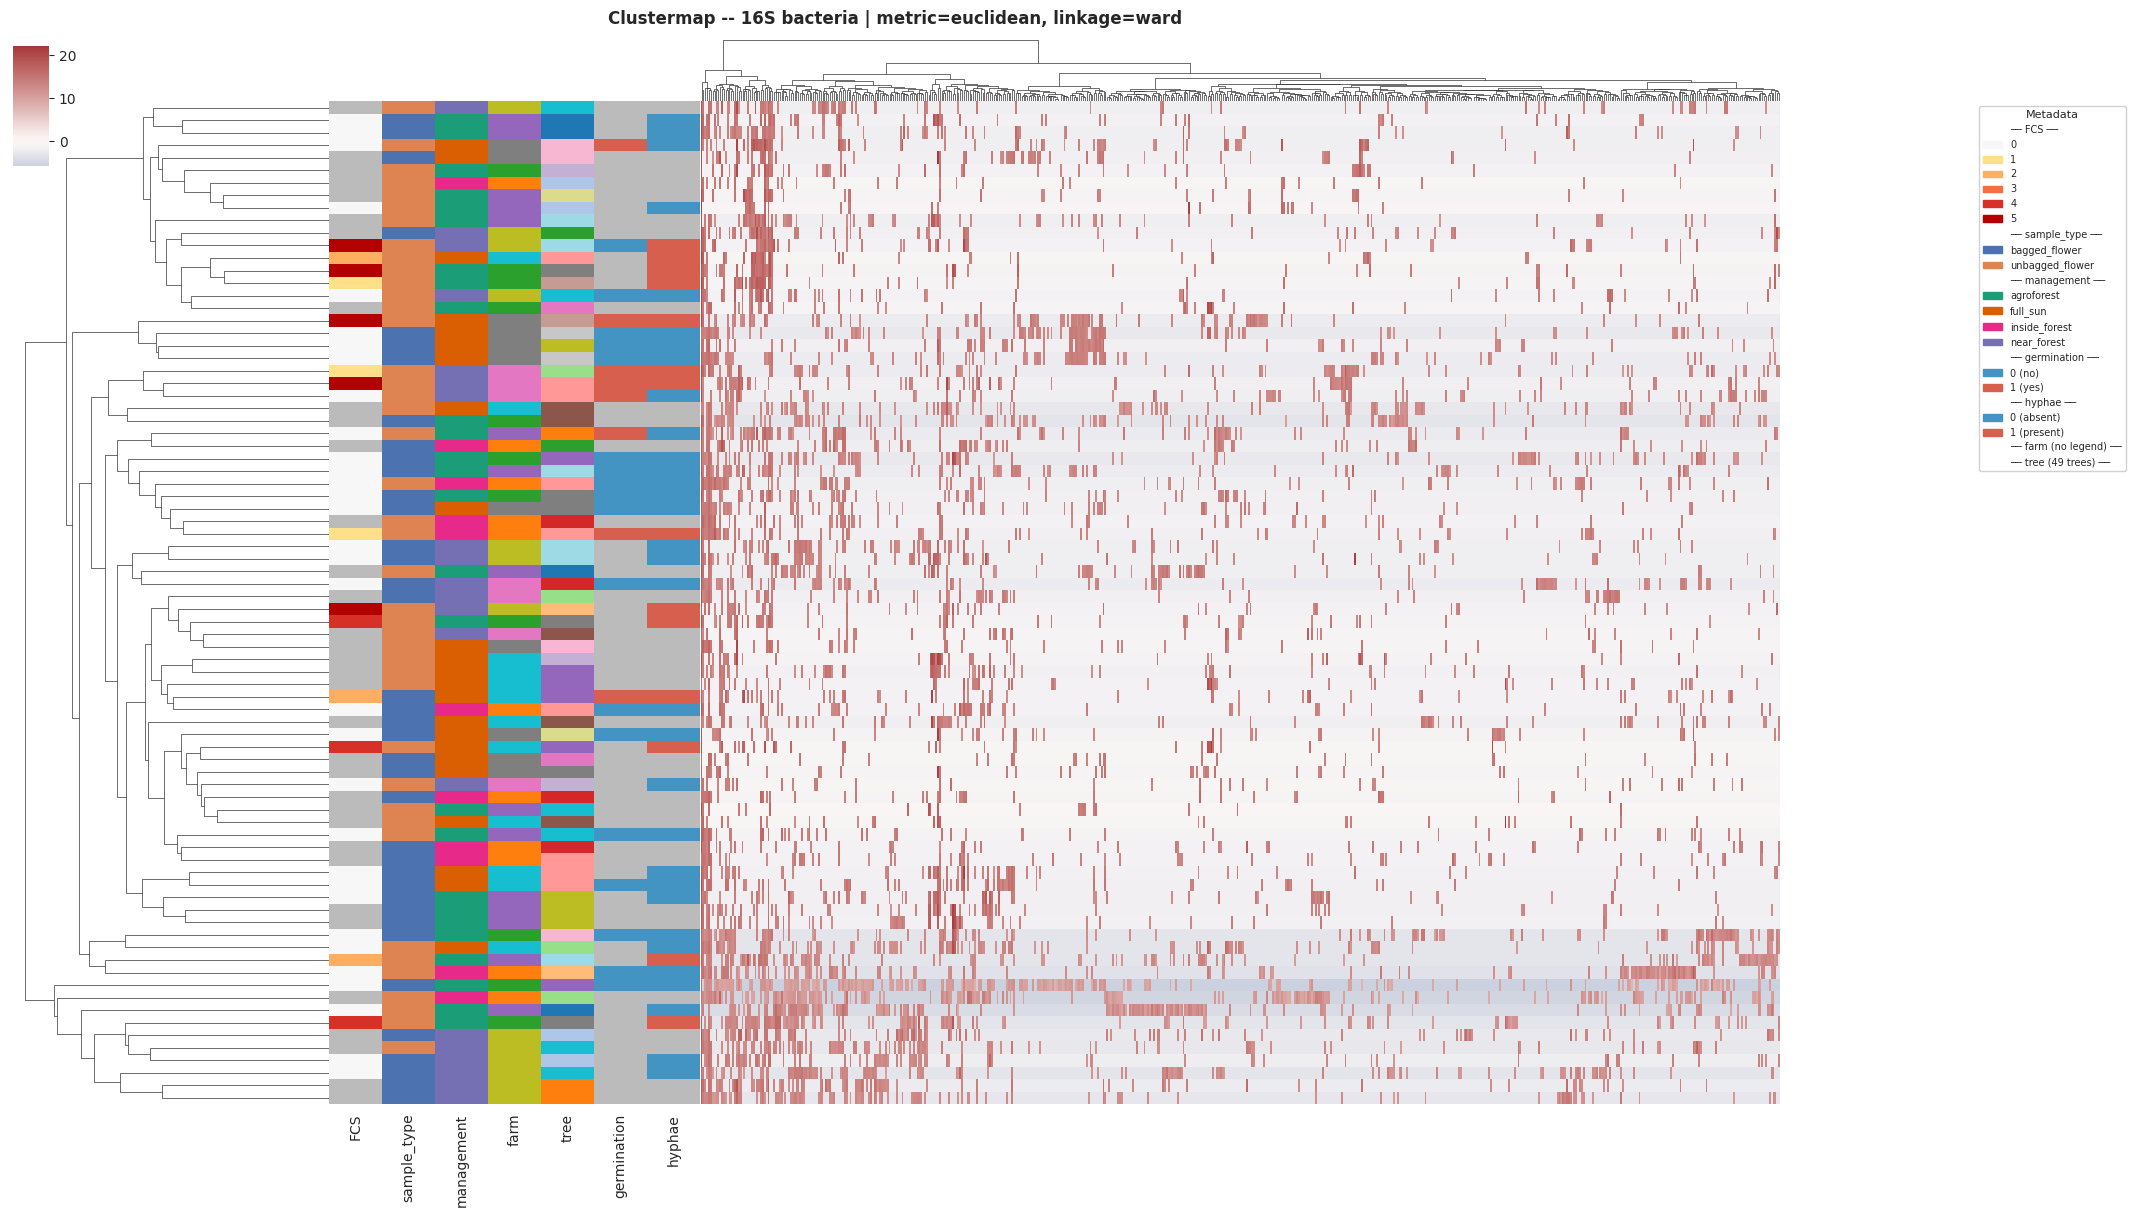


=== Hierarchical clusters (n=4) -- 16S bacteria ===
  Cluster 1 (n=70): management={'agroforest': 23, 'full_sun': 23, 'near_forest': 14, 'inside_forest': 10}
    sample_type={'unbagged_flower': 38, 'bagged_flower': 32}  mean_FCS=1.02
  Cluster 2 (n=8): management={'near_forest': 6, 'agroforest': 2}
    sample_type={'bagged_flower': 5, 'unbagged_flower': 3}  mean_FCS=1.00
  Cluster 3 (n=1): management={'inside_forest': 1}
    sample_type={'unbagged_flower': 1}  mean_FCS=nan
  Cluster 4 (n=1): management={'agroforest': 1}
    sample_type={'bagged_flower': 1}  mean_FCS=0.00


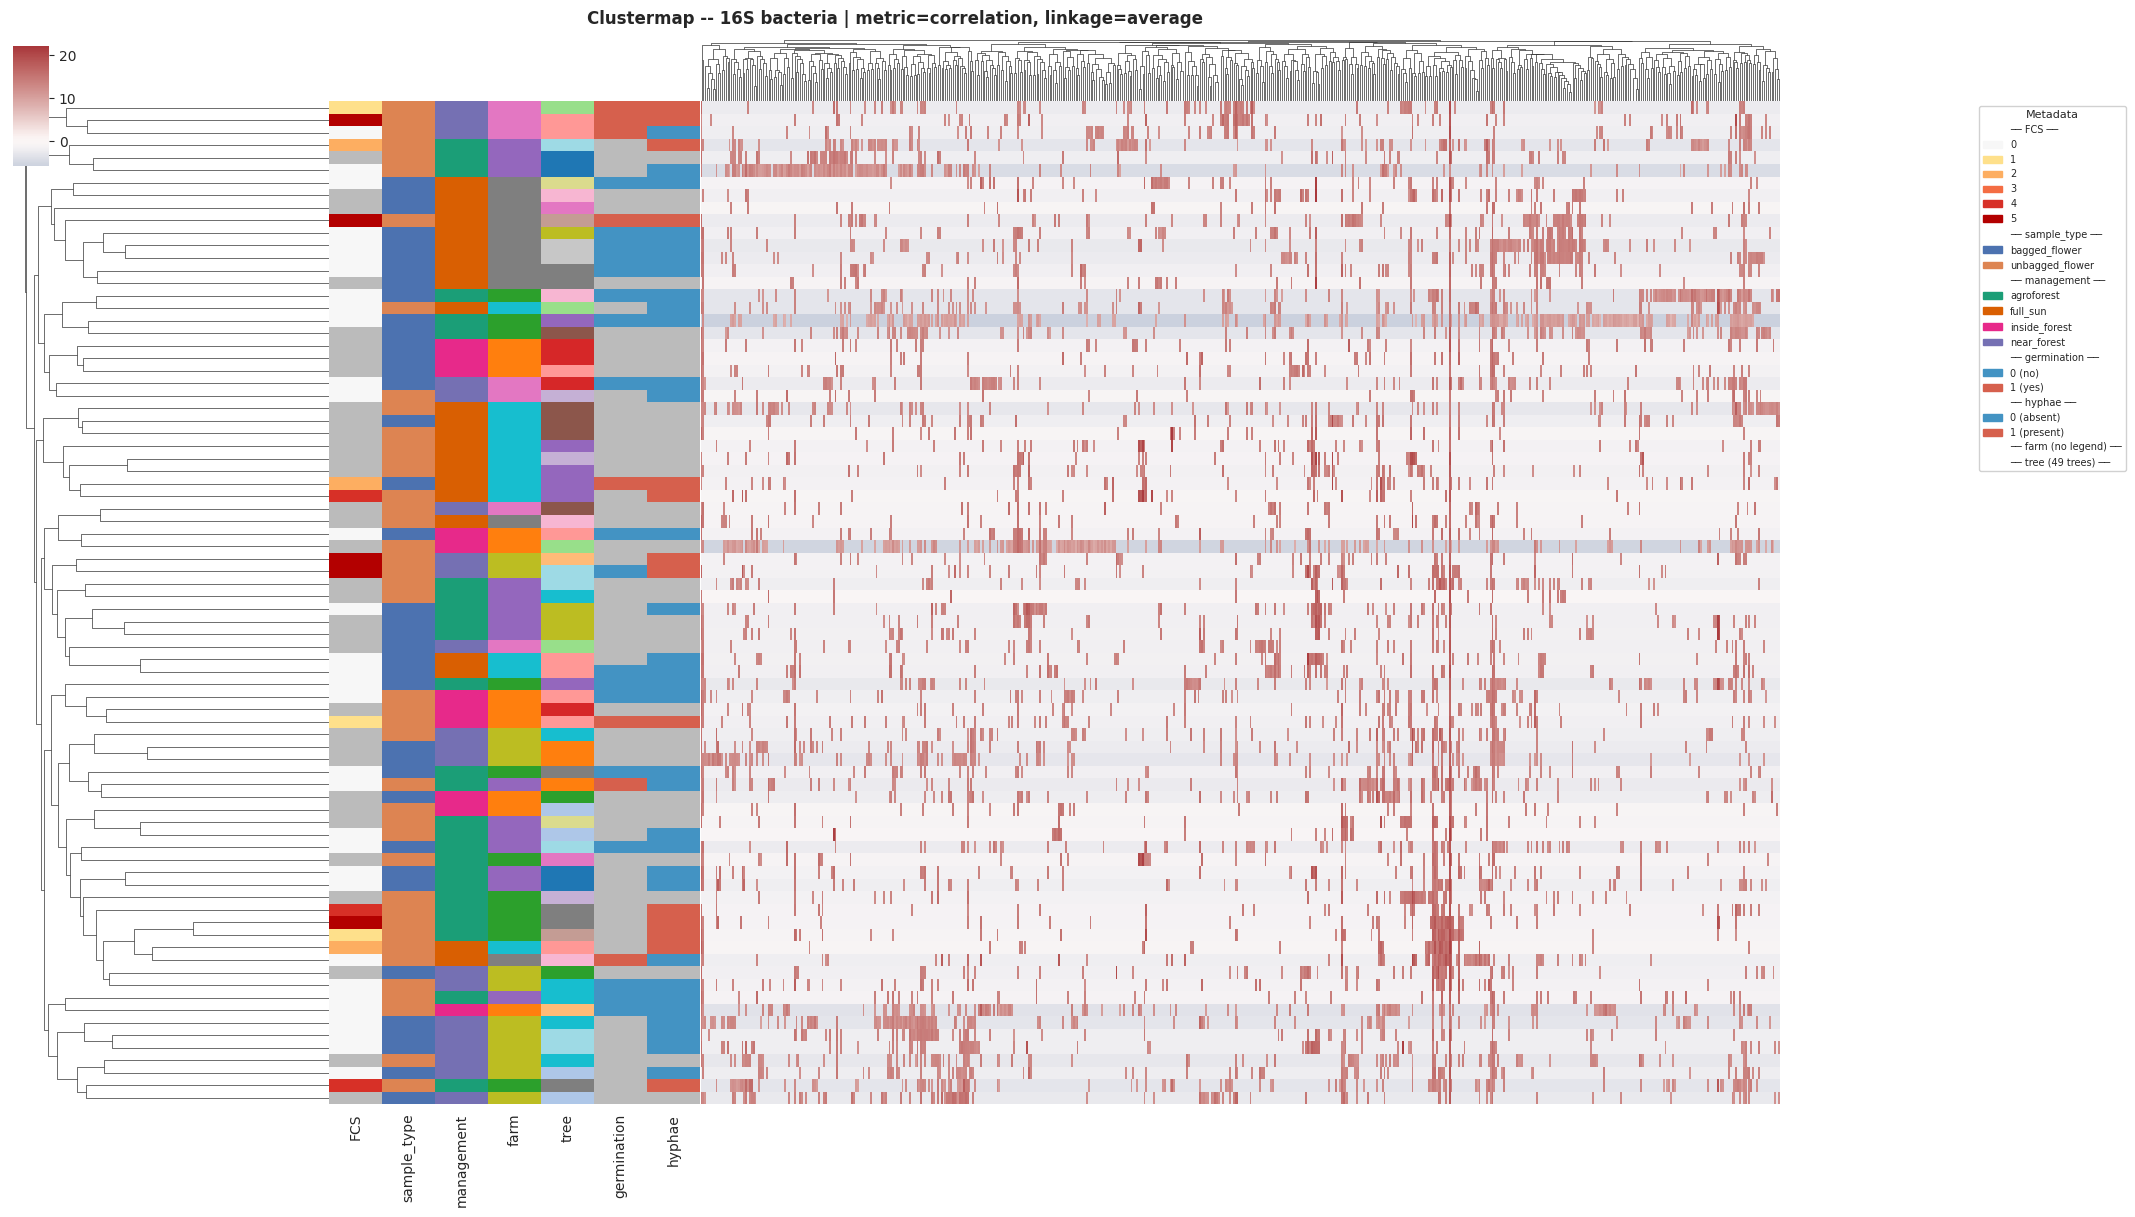


=== Hierarchical clusters (n=4) -- 16S bacteria ===
  Cluster 1 (n=3): management={'near_forest': 3}
    sample_type={'unbagged_flower': 3}  mean_FCS=2.00
  Cluster 2 (n=3): management={'agroforest': 3}
    sample_type={'unbagged_flower': 3}  mean_FCS=1.00
  Cluster 3 (n=18): management={'full_sun': 10, 'agroforest': 3, 'inside_forest': 3, 'near_forest': 2}
    sample_type={'bagged_flower': 15, 'unbagged_flower': 3}  mean_FCS=0.45
  Cluster 4 (n=56): management={'agroforest': 20, 'near_forest': 15, 'full_sun': 13, 'inside_forest': 8}
    sample_type={'unbagged_flower': 33, 'bagged_flower': 23}  mean_FCS=1.10


psa23    1
pkk73    4
cyb32    4
pmt23    4
pvr11    4
        ..
pvi13    3
cvr41    4
psa62    3
psa43    1
pyb62    4
Name: hc_cluster, Length: 80, dtype: int32

In [79]:
from scipy.cluster.hierarchy import fcluster, linkage as sp_linkage
from scipy.spatial.distance import pdist
import matplotlib.patches as mpatches

# ── Color lookup tables ───────────────────────────────────────────────────────
fcs_lut = {
    '0': '#F7F7F7', '1': '#FEE08B', '2': '#FDAE61',
    '3': '#F46D43', '4': '#D73027', '5': '#B30000', 'nan': '#BBBBBB'
}
st_lut = {'bagged_flower': '#4C72B0', 'unbagged_flower': '#DD8452'}
mgmt_lut = {
    'agroforest':    '#1B9E77',
    'full_sun':      '#D95F02',
    'inside_forest': '#E7298A',
    'near_forest':   '#7570B3',
    'nan':           '#BBBBBB',
}
germ_lut  = {'0': '#4393C3', '1': '#D6604D', 'nan': '#BBBBBB'}
hyphae_lut= {'0': '#4393C3', '1': '#D6604D', 'nan': '#BBBBBB'}

# farm_id: auto palette (no legend needed, too many)
_farm_vals = sorted(meta['farm_id'].dropna().unique())
_farm_pal  = dict(zip(_farm_vals, sns.color_palette('tab10', len(_farm_vals))))

# tree_id: 49 values, no legend
_tree_vals = sorted(meta['tree_id'].dropna().unique())
_tree_pal  = dict(zip(_tree_vals, sns.color_palette('tab20', len(_tree_vals))))


def _to_key(x, numeric=False):
    if pd.isna(x) or str(x).strip() in ('', 'nan'):
        return 'nan'
    if numeric:
        try: return str(int(float(x)))
        except: pass
    return str(x)


def make_row_colors_extended(meta_aligned):
    """Build multi-column row color DataFrame for clustermap."""
    idx = meta_aligned.index
    cols = {}

    cols['FCS']         = meta_aligned['fungal_colonization_score'].apply(
        lambda x: fcs_lut.get(_to_key(x, numeric=True), '#BBBBBB'))
    cols['sample_type'] = meta_aligned['sample_type'].apply(
        lambda x: st_lut.get(_to_key(x), '#BBBBBB'))
    cols['management']  = meta_aligned['management_type'].apply(
        lambda x: mgmt_lut.get(_to_key(x), '#BBBBBB'))
    cols['farm']        = meta_aligned['farm_id'].apply(
        lambda x: _farm_pal.get(_to_key(x), '#BBBBBB'))
    # tree_id: no legend (49 trees), just color strip for visual grouping
    cols['tree']        = meta_aligned['tree_id'].apply(
        lambda x: _tree_pal.get(_to_key(x), '#BBBBBB'))         if 'tree_id' in meta_aligned.columns else pd.Series('#BBBBBB', index=idx)
    cols['germination'] = meta_aligned['is_germination'].apply(
        lambda x: germ_lut.get(_to_key(x, numeric=True), '#BBBBBB'))
    cols['hyphae']      = meta_aligned['is_hyphae_present'].apply(
        lambda x: hyphae_lut.get(_to_key(x, numeric=True), '#BBBBBB'))

    return pd.DataFrame(cols, index=idx)


def plot_clustermap(clr_df, meta_aligned, name, metric='euclidean', method='ward',
                    n_clusters=4, n_max=80, random_state=42):
    """
    Clustermap with extended metadata annotation.
    Also cuts the row dendrogram into n_clusters groups and prints composition.

    Column dendrogram: groups ASVs with similar abundance profiles across samples
    (i.e. ASVs that are high/low in the same samples appear adjacent).
    This reflects co-variation of ASVs, not strict co-occurrence.
    """
    rng = np.random.default_rng(random_state)
    if len(clr_df) > n_max:
        idx = rng.choice(len(clr_df), n_max, replace=False)
        clr_sub  = clr_df.iloc[idx]
        meta_sub = meta_aligned.iloc[idx]
    else:
        clr_sub, meta_sub = clr_df.copy(), meta_aligned.copy()

    row_colors = make_row_colors_extended(meta_sub)

    g = sns.clustermap(
        clr_sub,
        metric=metric, method=method,
        cmap='vlag', center=0,
        row_colors=row_colors,
        figsize=(18, 12),
        xticklabels=False, yticklabels=False,
        dendrogram_ratio=(0.18, 0.06),
        cbar_pos=(0.01, 0.88, 0.02, 0.10),
        linewidths=0,
    )
    g.fig.suptitle(
        f'Clustermap -- {name} | metric={metric}, linkage={method}',
        y=1.01, fontsize=12, fontweight='bold'
    )

    # ── Legend ──────────────────────────────────────────────────────────
    legend_groups = [
        ("FCS", fcs_lut),
        ("sample_type", st_lut),
        ("management", mgmt_lut),
        ("germination", {"0 (no)": "#4393C3", "1 (yes)": "#D6604D"}),
        ("hyphae", {"0 (absent)": "#4393C3", "1 (present)": "#D6604D"}),
    ]
    handles = []
    for group_name, lut in legend_groups:
        handles.append(mpatches.Patch(color='none', label=f'── {group_name} ──'))
        for k, c in lut.items():
            if k != 'nan':
                handles.append(mpatches.Patch(color=c, label=k))
    handles.append(mpatches.Patch(color='none', label='── farm (no legend) ──'))
    handles.append(mpatches.Patch(color='none', label='── tree (49 trees) ──'))

    g.ax_heatmap.legend(
        handles=handles, bbox_to_anchor=(1.18, 1), loc='upper left',
        fontsize=7, title='Metadata', title_fontsize=8,
        frameon=True, framealpha=0.9
    )

    plt.show()

    # ── Cut dendrogram -> explicit cluster labels ─────────────────────
    # Row order reindexed by clustermap
    reordered_idx = clr_sub.index[g.dendrogram_row.reordered_ind]
    # Recompute linkage on the same data for fcluster
    Z = sp_linkage(pdist(clr_sub.values, metric=metric), method=method)
    flat_labels = fcluster(Z, t=n_clusters, criterion='maxclust')
    # Map back to original index order
    label_series = pd.Series(flat_labels, index=clr_sub.index, name='hc_cluster')

    print(f'\n=== Hierarchical clusters (n={n_clusters}) -- {name} ===')
    for k in sorted(label_series.unique()):
        members = label_series[label_series == k].index
        mgmt = meta_sub.loc[members, 'management_type'].value_counts().to_dict()
        st   = meta_sub.loc[members, 'sample_type'].value_counts().to_dict()
        fcs  = meta_sub.loc[members, 'fungal_colonization_score'].mean()
        print(f'  Cluster {k} (n={len(members)}): management={mgmt}')
        print(f'    sample_type={st}  mean_FCS={fcs:.2f}')

    g.fig.savefig(FIG_DIR / f'clustermap_{name.replace(" ","_")}_{metric}_{method}.pdf',
                  bbox_inches='tight')
    return label_series


# ── Run for 16S (ward is best for compact clusters) ──────────────────────────
hc_labels_16s = plot_clustermap(
    clr_16s, meta_16s, '16S bacteria',
    metric='euclidean', method='ward', n_clusters=4, n_max=80
)

# ── Correlation distance (no ward, use average) ───────────────────────────────
plot_clustermap(
    clr_16s, meta_16s, '16S bacteria',
    metric='correlation', method='average', n_clusters=4, n_max=80
)

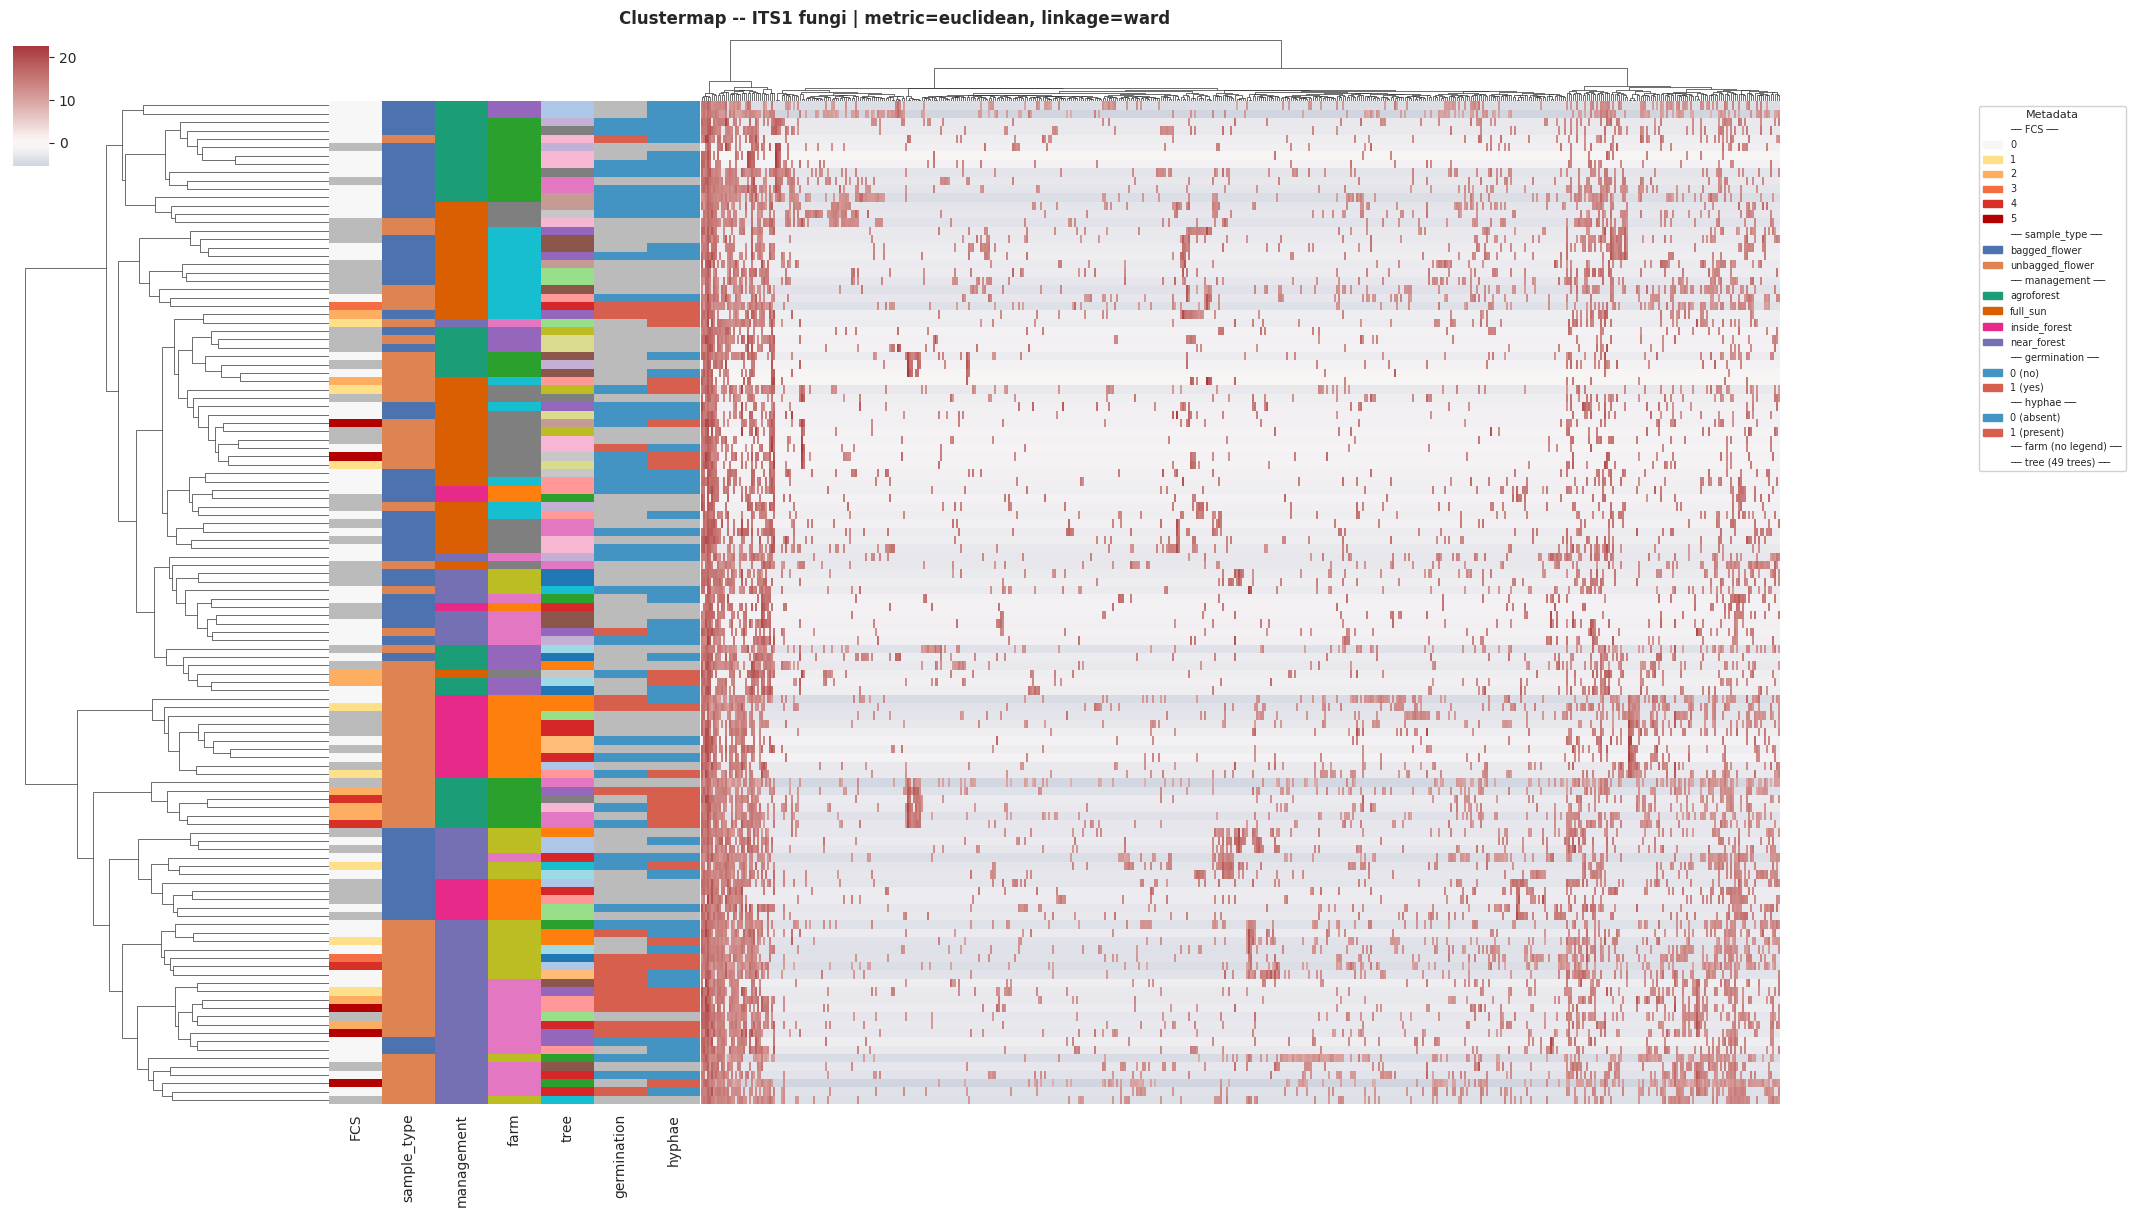


=== Hierarchical clusters (n=4) -- ITS1 fungi ===
  Cluster 1 (n=71): management={'full_sun': 35, 'agroforest': 23, 'near_forest': 10, 'inside_forest': 3}
    sample_type={'bagged_flower': 42, 'unbagged_flower': 29}  mean_FCS=0.55
  Cluster 2 (n=10): management={'inside_forest': 10}
    sample_type={'unbagged_flower': 10}  mean_FCS=0.40
  Cluster 3 (n=6): management={'agroforest': 6}
    sample_type={'unbagged_flower': 6}  mean_FCS=2.80
  Cluster 4 (n=33): management={'near_forest': 28, 'inside_forest': 5}
    sample_type={'unbagged_flower': 20, 'bagged_flower': 13}  mean_FCS=1.21


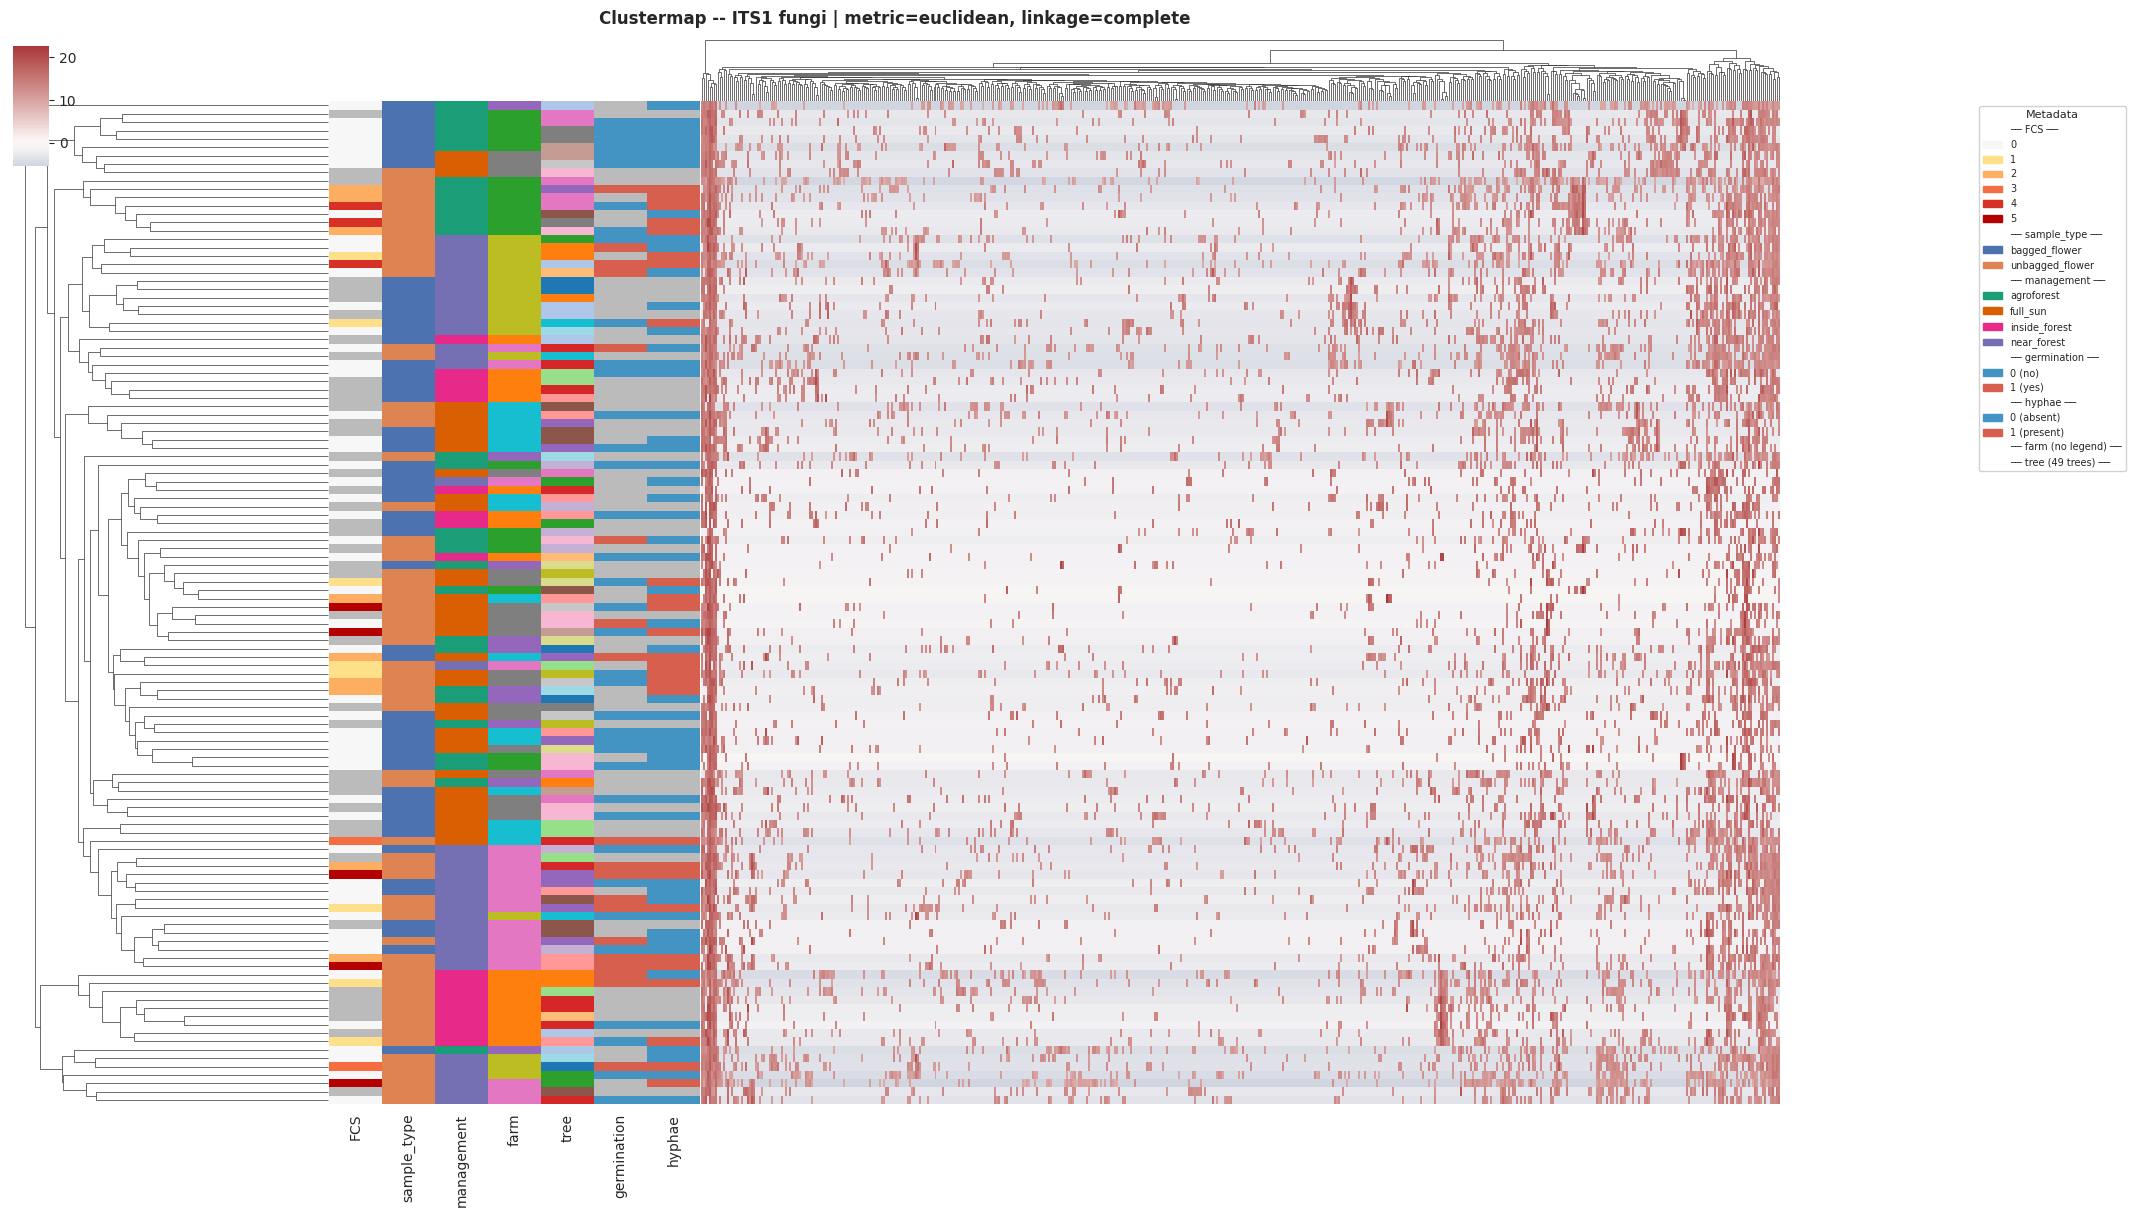


=== Hierarchical clusters (n=4) -- ITS1 fungi ===
  Cluster 1 (n=103): management={'full_sun': 35, 'near_forest': 32, 'agroforest': 27, 'inside_forest': 9}
    sample_type={'bagged_flower': 53, 'unbagged_flower': 50}  mean_FCS=0.88
  Cluster 2 (n=9): management={'inside_forest': 9}
    sample_type={'unbagged_flower': 9}  mean_FCS=0.50
  Cluster 3 (n=7): management={'near_forest': 6, 'agroforest': 1}
    sample_type={'unbagged_flower': 6, 'bagged_flower': 1}  mean_FCS=1.33
  Cluster 4 (n=1): management={'agroforest': 1}
    sample_type={'bagged_flower': 1}  mean_FCS=0.00


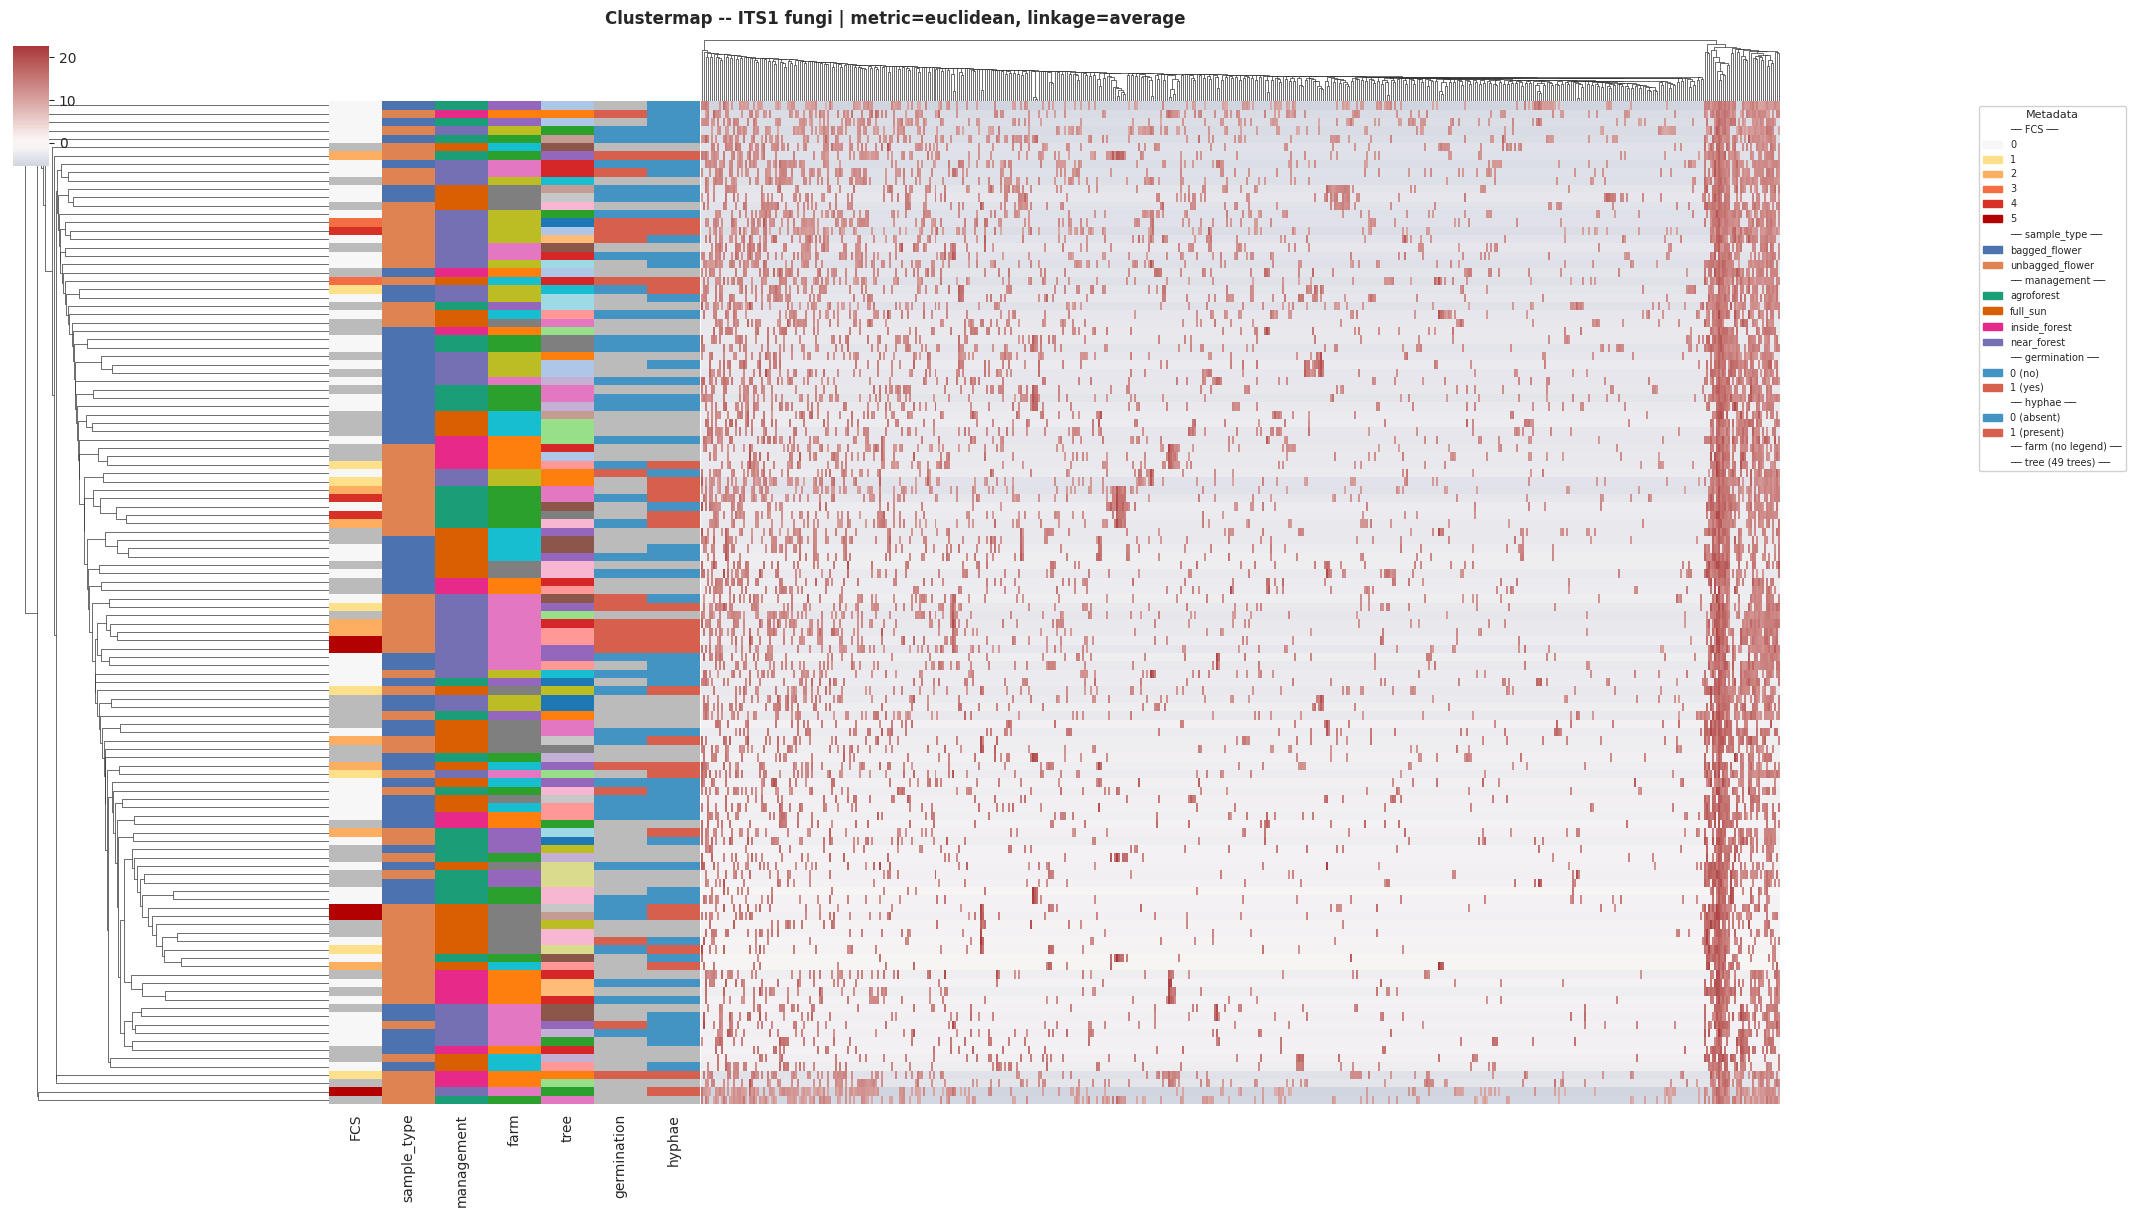


=== Hierarchical clusters (n=4) -- ITS1 fungi ===
  Cluster 1 (n=117): management={'near_forest': 37, 'full_sun': 35, 'agroforest': 27, 'inside_forest': 18}
    sample_type={'unbagged_flower': 63, 'bagged_flower': 54}  mean_FCS=0.84
  Cluster 2 (n=1): management={'near_forest': 1}
    sample_type={'unbagged_flower': 1}  mean_FCS=5.00
  Cluster 3 (n=1): management={'agroforest': 1}
    sample_type={'unbagged_flower': 1}  mean_FCS=nan
  Cluster 4 (n=1): management={'agroforest': 1}
    sample_type={'bagged_flower': 1}  mean_FCS=0.00


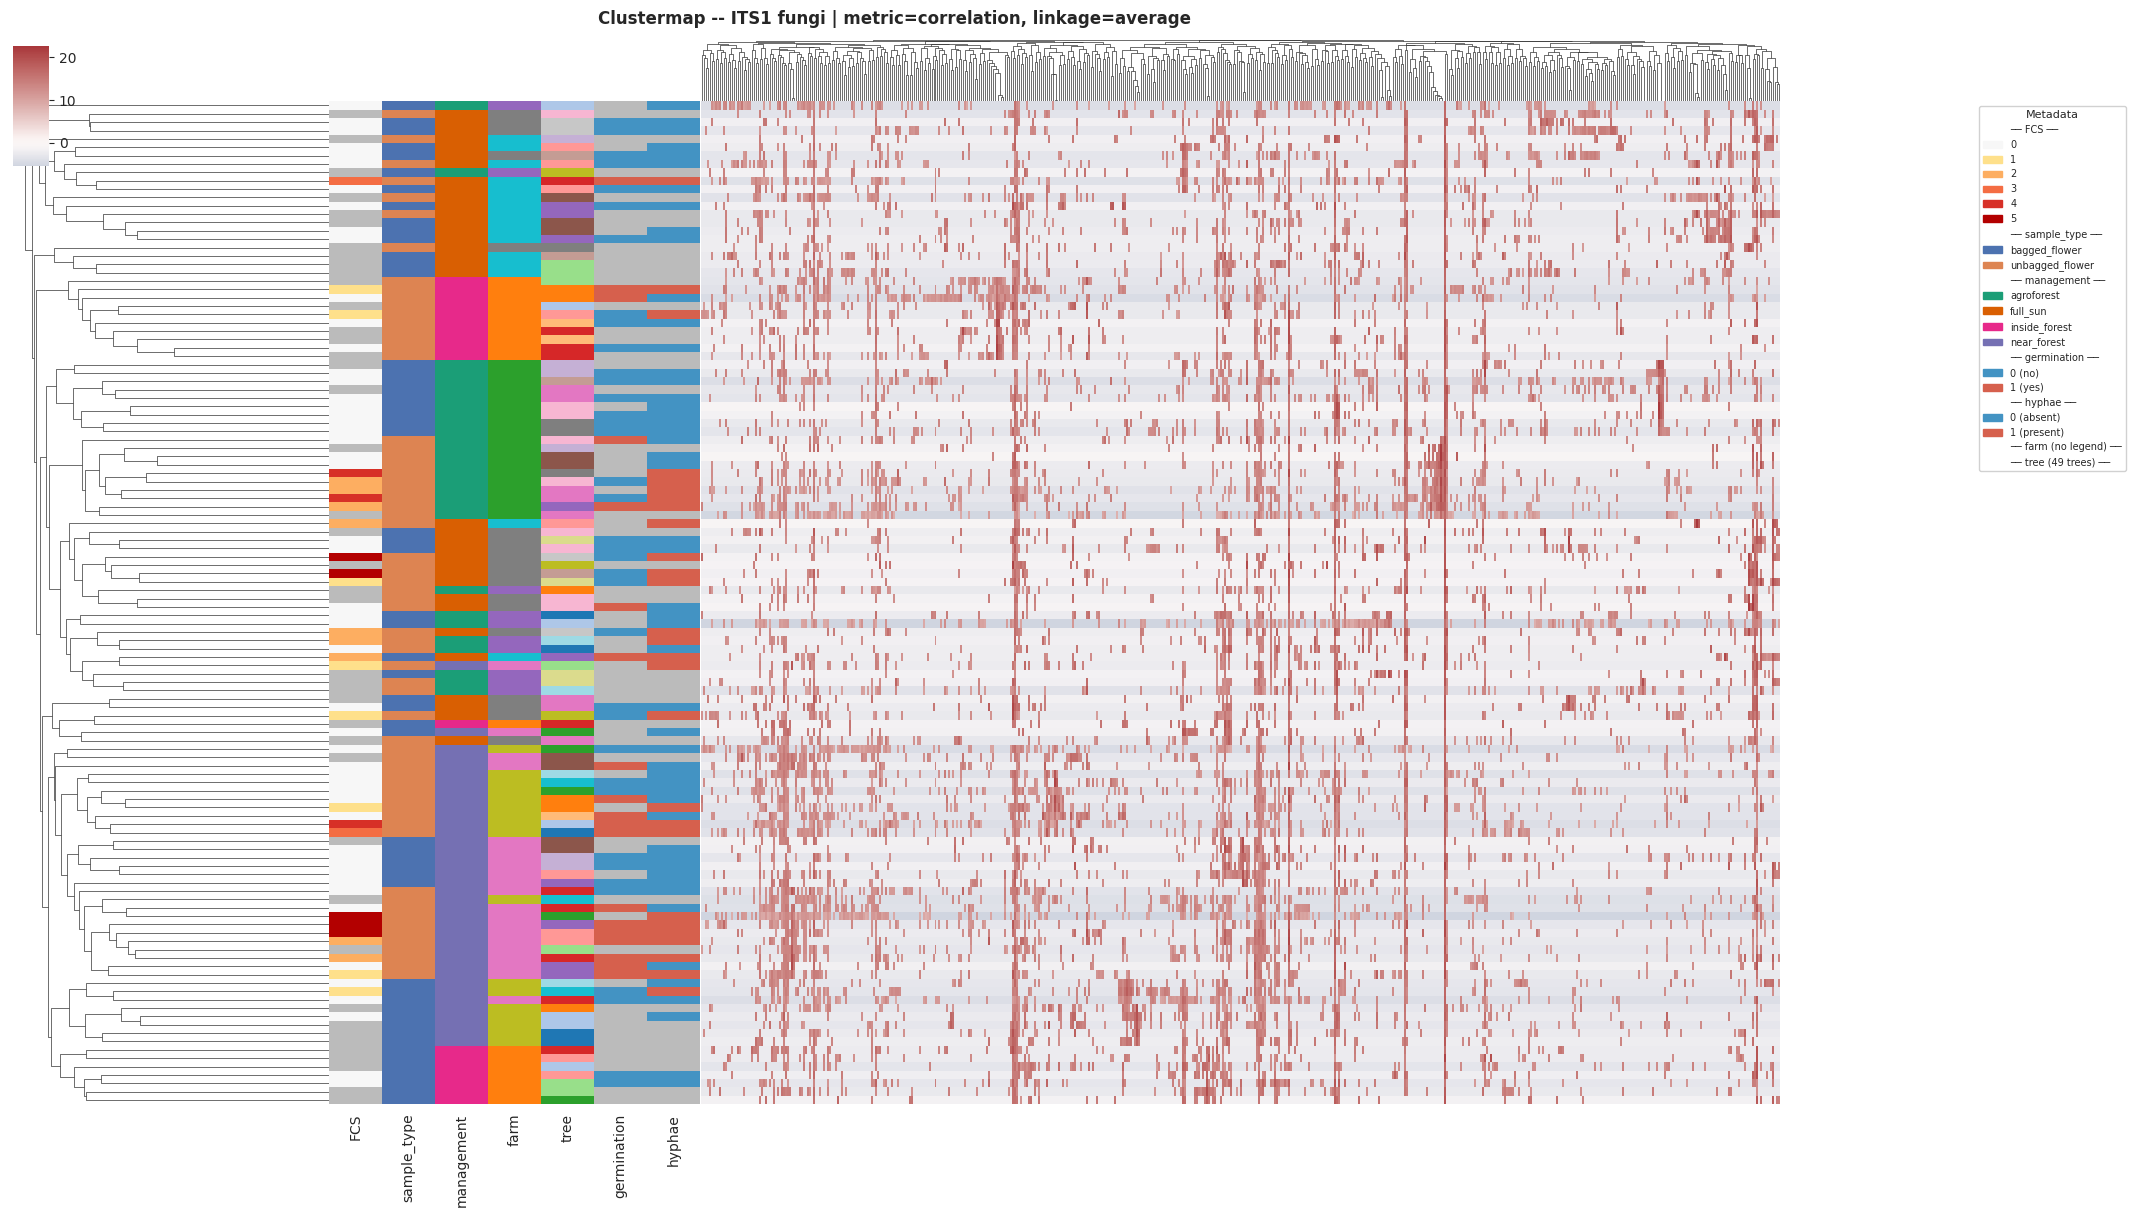


=== Hierarchical clusters (n=4) -- ITS1 fungi ===
  Cluster 1 (n=16): management={'full_sun': 15, 'agroforest': 1}
    sample_type={'bagged_flower': 10, 'unbagged_flower': 6}  mean_FCS=0.30
  Cluster 2 (n=4): management={'full_sun': 4}
    sample_type={'bagged_flower': 3, 'unbagged_flower': 1}  mean_FCS=nan
  Cluster 3 (n=99): management={'near_forest': 38, 'agroforest': 27, 'inside_forest': 18, 'full_sun': 16}
    sample_type={'unbagged_flower': 58, 'bagged_flower': 41}  mean_FCS=0.99
  Cluster 4 (n=1): management={'agroforest': 1}
    sample_type={'bagged_flower': 1}  mean_FCS=0.00


psa53    3
pvi11    3
cib13    3
cyb63    1
cmt62    4
        ..
ckk63    3
cib42    3
cmt61    3
pvr12    3
csa72    3
Name: hc_cluster, Length: 120, dtype: int32

In [80]:
# ITS1: often smaller dataset, use all samples
for method in ['ward', 'complete', 'average']:
    plot_clustermap(clr_its1, meta_its1, 'ITS1 fungi', metric='euclidean', method=method,
                   n_max=120)

plot_clustermap(clr_its1, meta_its1, 'ITS1 fungi', metric='correlation', method='average',
               n_max=120)

## 8. Silhouette plot comparison -- best models per dataset

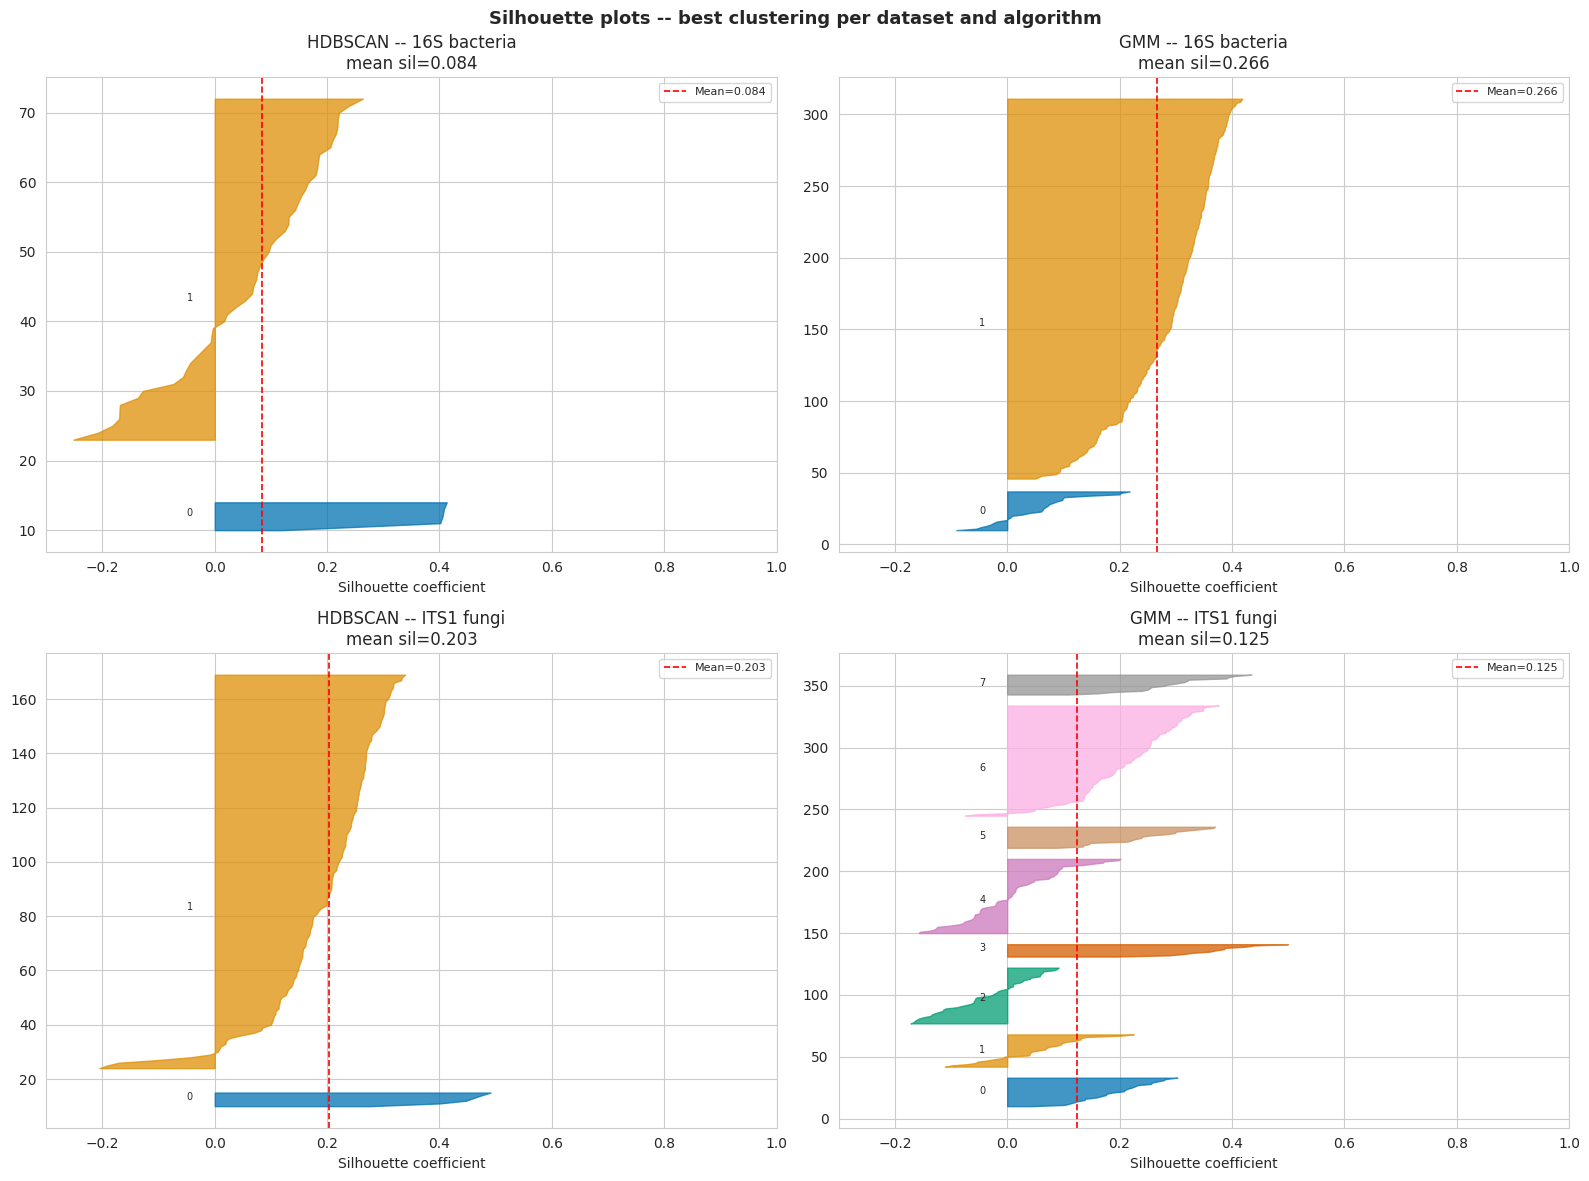

In [81]:
def silhouette_plot(pcs, labels, title, ax):
    """Draw silhouette plot on a given axis."""
    non_noise  = labels != -1
    lbl_clean  = labels[non_noise]
    X_clean    = pcs[non_noise]
    if len(set(lbl_clean)) < 2:
        ax.set_title(f'{title}\n(< 2 clusters, cannot compute)')
        return
    sil_vals   = silhouette_samples(X_clean, lbl_clean)
    mean_sil   = sil_vals.mean()
    unique_lbl = np.unique(lbl_clean)
    pal        = sns.color_palette('colorblind', len(unique_lbl))
    y_lower    = 10
    for k, color in zip(unique_lbl, pal):
        kth = np.sort(sil_vals[lbl_clean == k])
        y_upper = y_lower + len(kth)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, kth,
                         facecolor=color, edgecolor=color, alpha=0.75)
        ax.text(-0.05, y_lower + 0.4 * len(kth), str(k), fontsize=7)
        y_lower = y_upper + 8
    ax.axvline(mean_sil, color='red', linestyle='--', linewidth=1.2,
               label=f'Mean={mean_sil:.3f}')
    ax.set(title=f'{title}\nmean sil={mean_sil:.3f}',
           xlabel='Silhouette coefficient', xlim=[-0.3, 1.0])
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Silhouette plots -- best clustering per dataset and algorithm',
             fontsize=13, fontweight='bold')

silhouette_plot(pcs_16s,  hdb_labels_16s,  'HDBSCAN -- 16S bacteria',  axes[0, 0])
silhouette_plot(pcs_16s,  gmm_labels_16s,  'GMM -- 16S bacteria',      axes[0, 1])
silhouette_plot(pcs_its1, hdb_labels_its1, 'HDBSCAN -- ITS1 fungi',    axes[1, 0])
silhouette_plot(pcs_its1, gmm_labels_its1, 'GMM -- ITS1 fungi',        axes[1, 1])

plt.tight_layout()
plt.savefig(FIG_DIR / 'silhouette_comparison.pdf', bbox_inches='tight')
plt.show()

## 9. Summary

**Your observations here:**

- Does `fungal_colonization_score` align with ITS1 clusters?
- Does `sample_type` (bagged vs unbagged) drive 16S clustering?
- Which algorithm (HDBSCAN vs GMM) gives more biologically interpretable clusters?
- What does the clustermap dendogram reveal about ASV co-occurrence patterns?

In [82]:
# Quick summary table
summary = []
for name, pcs, lbl in [
    ('HDBSCAN 16S',  pcs_16s,  hdb_labels_16s),
    ('GMM 16S',      pcs_16s,  gmm_labels_16s),
    ('HDBSCAN ITS1', pcs_its1, hdb_labels_its1),
    ('GMM ITS1',     pcs_its1, gmm_labels_its1),
]:
    non_noise = lbl != -1
    lbl_c = lbl[non_noise]; X_c = pcs[non_noise]
    n_cl = len(set(lbl_c))
    sil  = silhouette_score(X_c, lbl_c) if n_cl >= 2 else np.nan
    ch   = calinski_harabasz_score(X_c, lbl_c) if n_cl >= 2 else np.nan
    summary.append({'Model': name, 'Clusters': n_cl,
                    'Noise': f"{(~non_noise).mean():.1%}",
                    'Silhouette': f'{sil:.4f}' if not np.isnan(sil) else 'N/A',
                    'Calinski-Harabasz': f'{ch:.1f}' if not np.isnan(ch) else 'N/A'})

print(pd.DataFrame(summary).set_index('Model').to_string())

              Clusters  Noise Silhouette Calinski-Harabasz
Model                                                     
HDBSCAN 16S          2  81.3%     0.0837               4.4
GMM 16S              2   0.0%     0.2660              26.4
HDBSCAN ITS1         2  48.3%     0.2027               9.6
GMM ITS1             8   0.0%     0.1247              23.9
